1. Importación de paquetes:

In [1]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# Modelado
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
COLOR_MAIN = '#E84855'
COLOR_SEC  = '#4A90D9'
COLOR_TERC = '#2D6A4F'

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


2. Leectura de csv:

Filas y columnas iniciales: (25000, 79)
id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object
calendar_updated               25000
host_neighbourhood             17078
license                        15812
neighborhood_overview          14414
neighbourhood                  14414
host_about                     12402
host_location                   8150
price                           6047
estimated_revenue_l365

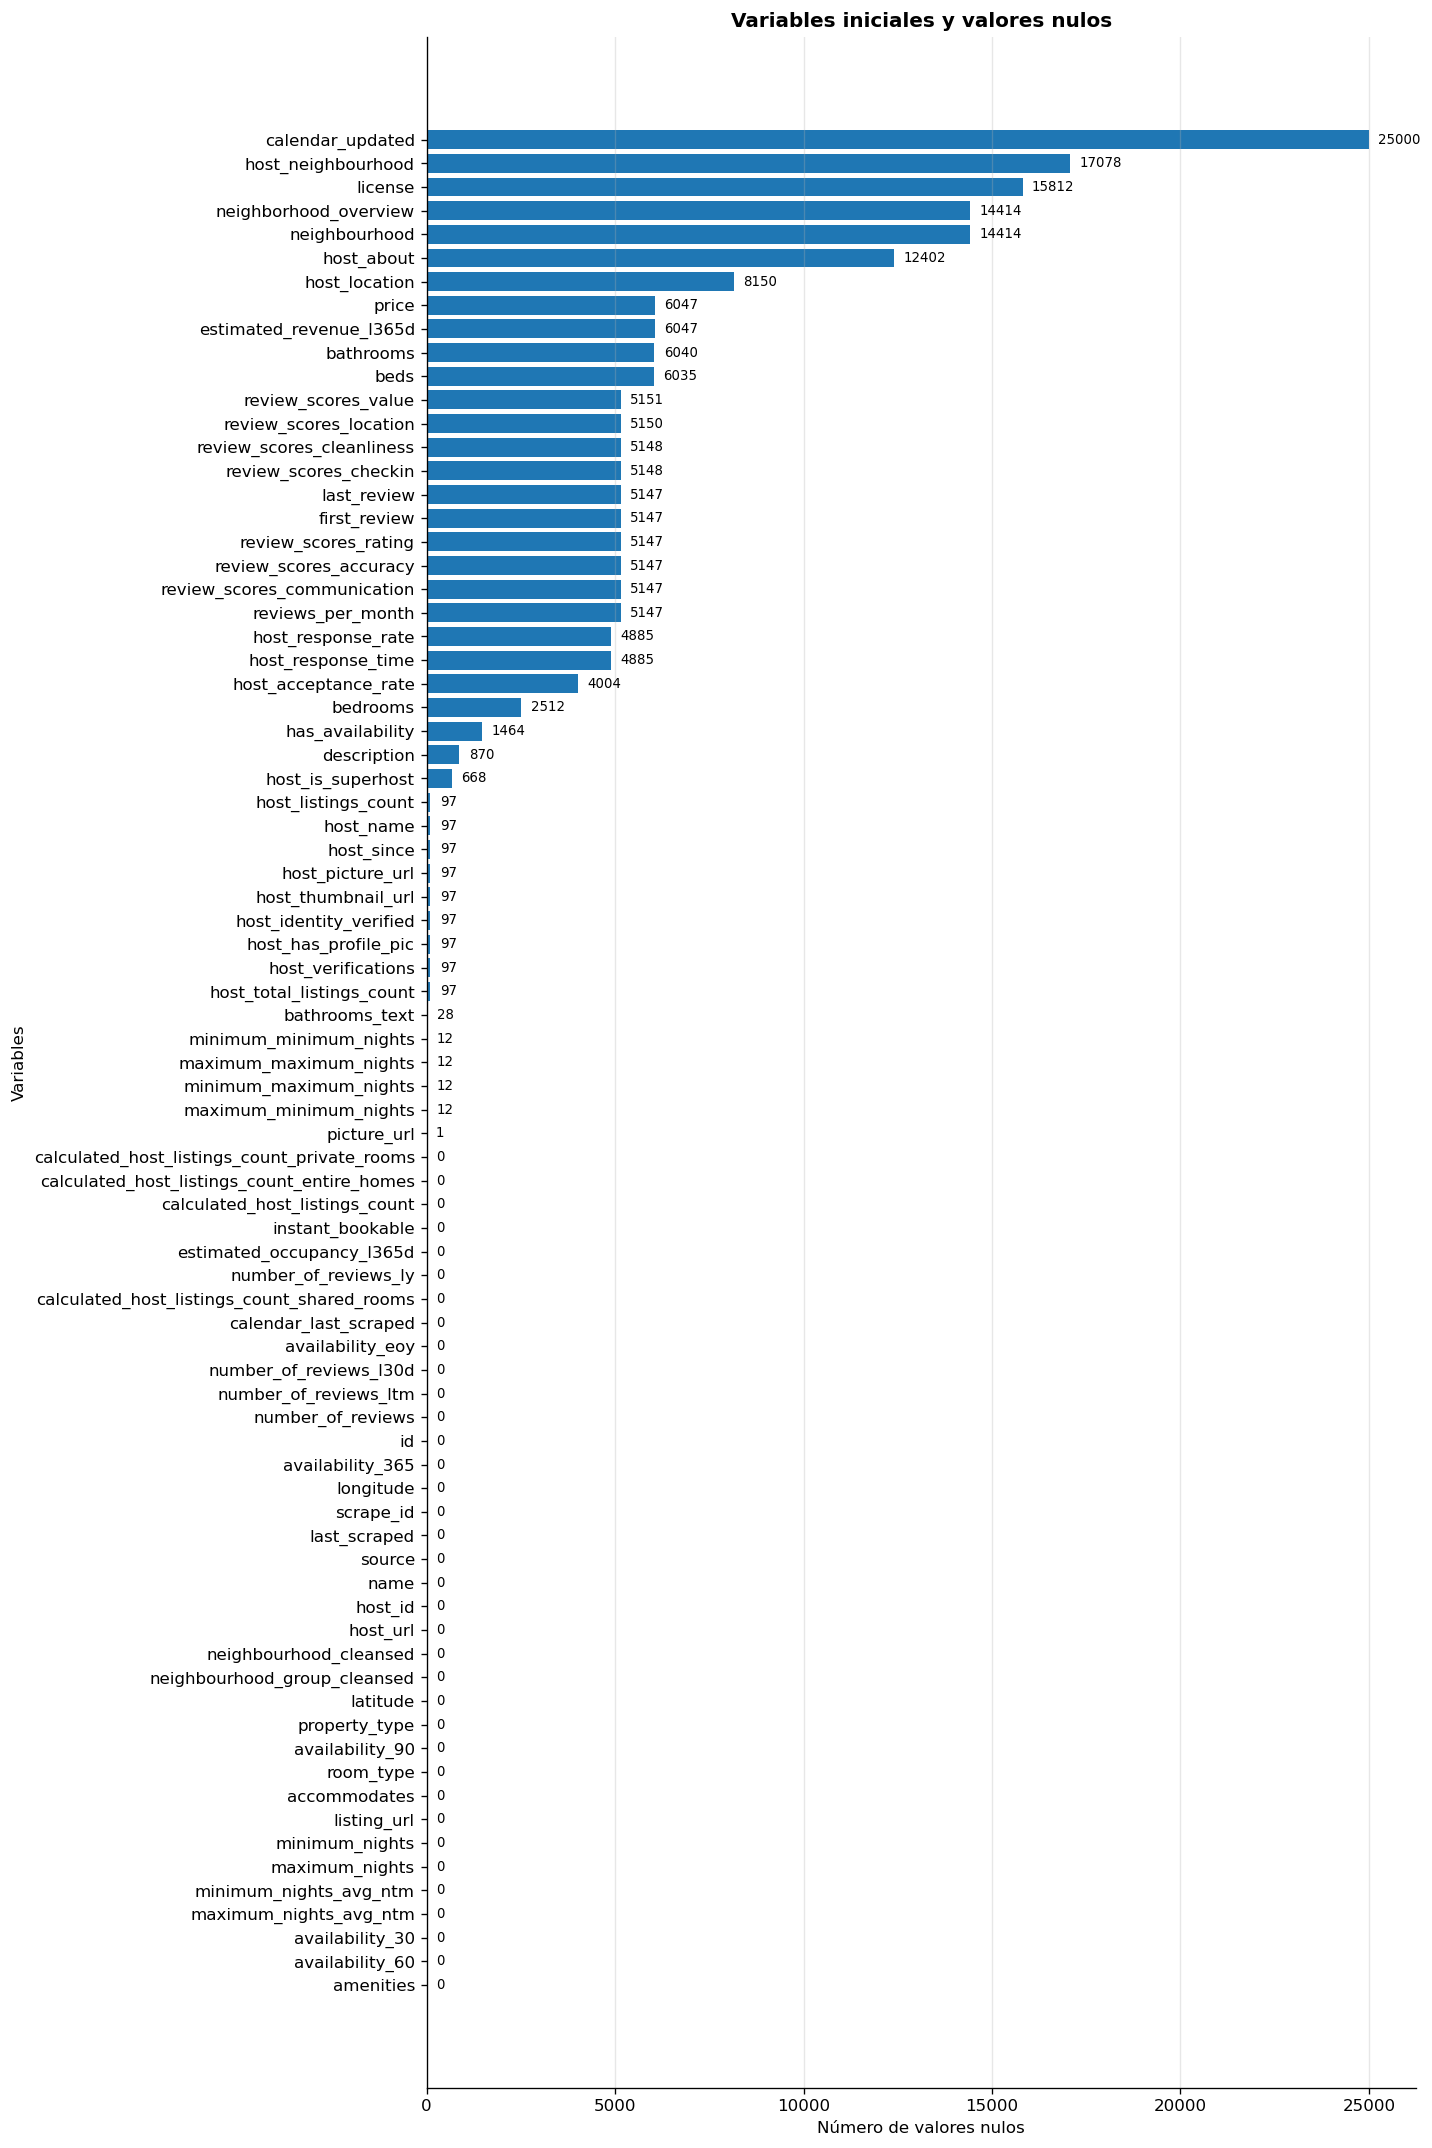

In [2]:
#2.1 CARGA DEL CSV:
listings = pd.read_csv('/Users/luciagonzalezdavila/Documents/4º/TFG/BBDD airbnb/listings.csv')

#2.2 EXPLORACIÓN INICIAL: 
#2.2.1Filas y columnas: 
print("Filas y columnas iniciales:", listings.shape)

#2.2.2Tipos de variables: 
print(listings.dtypes)

#2.2.3Exploración de las variables numéricas: 
listings.describe()

#2.2.4Nulos:
print(listings.isnull().sum().sort_values(ascending=False).head(20))

#2.2.5 VISUALIZACIÓN DE LAS VARIABLES INICIALES Y VALORES NULOS:
null_counts = listings.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(12,18))
bars = plt.barh(null_counts.index[::-1], null_counts.values[::-1])
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(null_counts) * 0.01,         
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=8
    )
plt.xlabel("Número de valores nulos")
plt.ylabel("Variables")
plt.title("Variables iniciales y valores nulos")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



### 2.3 Estadísticos descriptivos iniciales

In [3]:
# Tabla de estadísticos descriptivos de las variables clave (antes de limpieza)
vars_desc = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
             'number_of_reviews', 'review_scores_rating',
             'availability_365', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']
vars_presentes = [v for v in vars_desc if v in listings.columns]

desc = listings[vars_presentes].describe().T
desc['cv'] = (desc['std'] / desc['mean']).round(3)   # coeficiente de variación
desc = desc[['count','mean','std','min','25%','50%','75%','max','cv']].round(2)
print("Tabla 1. Estadísticos descriptivos iniciales")
print(desc.to_string())
print("\nFuente: elaboración propia a partir de Inside Airbnb (sept. 2025)")

Tabla 1. Estadísticos descriptivos iniciales
                             count      mean       std  min     25%      50%       75%        max    cv
accommodates               25000.0      3.17      1.92  1.0    2.00     3.00      4.00       16.0  0.61
bedrooms                   22488.0      1.43      0.97  0.0    1.00     1.00      2.00       25.0  0.68
beds                       18965.0      1.99      1.52  0.0    1.00     2.00      2.00       40.0  0.77
bathrooms                  18960.0      1.31      0.70  0.0    1.00     1.00      1.50       19.0  0.54
number_of_reviews          25000.0     51.04     96.16  0.0    1.00    11.00     56.00     1184.0  1.88
review_scores_rating       19853.0      4.63      0.51  1.0    4.53     4.75      4.92        5.0  0.11
availability_365           25000.0    169.52    134.46  0.0   22.00   172.00    302.00      365.0  0.79
estimated_occupancy_l365d  25000.0     82.85     97.41  0.0    0.00    30.00    162.00      255.0  1.18
estimated_revenue_l

In [4]:
#Ver NaN y string vacias (¿coinciden con null?)
Total_blanco_null_NaN= listings.isnull().sum() + (listings == "").sum()
Total_blanco_null_NaN = Total_blanco_null_NaN[Total_blanco_null_NaN > 0].sort_values(ascending=False)
print(Total_blanco_null_NaN)

calendar_updated               25000
host_neighbourhood             17078
license                        15812
neighborhood_overview          14414
neighbourhood                  14414
host_about                     12402
host_location                   8150
price                           6047
estimated_revenue_l365d         6047
bathrooms                       6040
beds                            6035
review_scores_value             5151
review_scores_location          5150
review_scores_checkin           5148
review_scores_cleanliness       5148
first_review                    5147
reviews_per_month               5147
last_review                     5147
review_scores_rating            5147
review_scores_accuracy          5147
review_scores_communication     5147
host_response_rate              4885
host_response_time              4885
host_acceptance_rate            4004
bedrooms                        2512
has_availability                1464
description                      870
h

3. Diseño de las columnas: 

In [5]:
#3.1 VISUALIZACIÓN DE COLUMNAS:
cols = [
    "id",
    "host_id",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "price",
    "minimum_nights",
    "maximum_nights",
    "latitude",
    "longitude",
    "neighbourhood_cleansed",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "reviews_per_month",
    "host_since",
    "host_is_superhost",
    "instant_bookable",
    "amenities",
    "calculated_host_listings_count",
    "availability_365",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]


print(listings.columns.tolist())
print(len(listings.columns))

#3.2 REORGANIZACIÓN: 
#Filtrar columnas para que solo se quede con las que he mencionado: 
listings = listings[cols]
#Renombrar columnas: 
listings = listings.rename(columns={"id": "listing_id"})

#Limpieza en precio: 
listings["price"] = listings["price"].replace(r"[\$,]", "", regex=True).astype(float)

#Limpieza en baños: 
#a)Convertir a nuemrico y si es raro en missing:
listings["bathrooms"] = pd.to_numeric(listings["bathrooms"], errors="coerce")
#b)Ver si faltaban datos:
listings["bathrooms_missing"] = listings["bathrooms"].isna().astype(int)
#c)Rellenar los valores faltanntes con 0 y usar la mediana (evita outliers, no distorsiona)
listings["bathrooms"] = listings["bathrooms"].fillna(listings["bathrooms"].median())


#Limpieza en anfitrión (binaria): 
listings["host_is_superhost"] = listings["host_is_superhost"].map({"t":1, "f":0}).fillna(0)

#Limpieza en booking(binaria): 
listings["instant_bookable"] = listings["instant_bookable"].map({"t":1, "f":0}).fillna(0)

#Limpieza en amenities (de semiestructutrado a variables cuantitativas): 
#a)Creación de una función que devuelve una lista vacia si no hay datos y convierte las string en listas reales sin errores:
def parse_amenities(x):
    if pd.isna(x) or x == "":
        return []
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else []
    except:
        return []
#b)Aplicamos la función [conivierte la columna en listas realies]:
listings["amenities_list"] = listings["amenities"].apply(parse_amenities)
#c)Cuenta correctamente el número real:
listings["amenities_count"] = listings["amenities_list"].apply(len)
#d)Ver si tiene wifi:
listings["has_wifi"] = listings["amenities_list"].apply(lambda x: int("Wifi" in x))


#Limpieza en fecha alojamiento: 
listings["host_since"] = pd.to_datetime(listings["host_since"], errors="coerce")
#Fecha fija para que sea reproducible:
reference_date = pd.Timestamp("2025-12-01")
listings["host_tenure_days"] =  (reference_date - listings["host_since"]).dt.days


['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [6]:
#3.3 CREACIÓN DE NUEVAS COLUMNAS:
#RevPAR
listings["revpar"] = listings["estimated_revenue_l365d"] / 365
#Ocupación:
listings["occupancy_rate"] = listings["estimated_occupancy_l365d"] / 365


#ADR (APX, solo chequeo):
listings["adr_check"] = listings["estimated_revenue_l365d"] / listings["estimated_occupancy_l365d"].replace(0, np.nan)
#Otras variables (derivativas): 
# Precio por persona (evitando división entre 0):
listings["accommodates"] = listings["accommodates"].replace(0, 1)
listings["price_per_person"] = listings["price"] / listings["accommodates"]
# Host profesional (considero profesional si tiene más de un alojamiento):
listings["professional_host"] = (listings["calculated_host_listings_count"] > 1).astype(int)


4. Limpieza: 

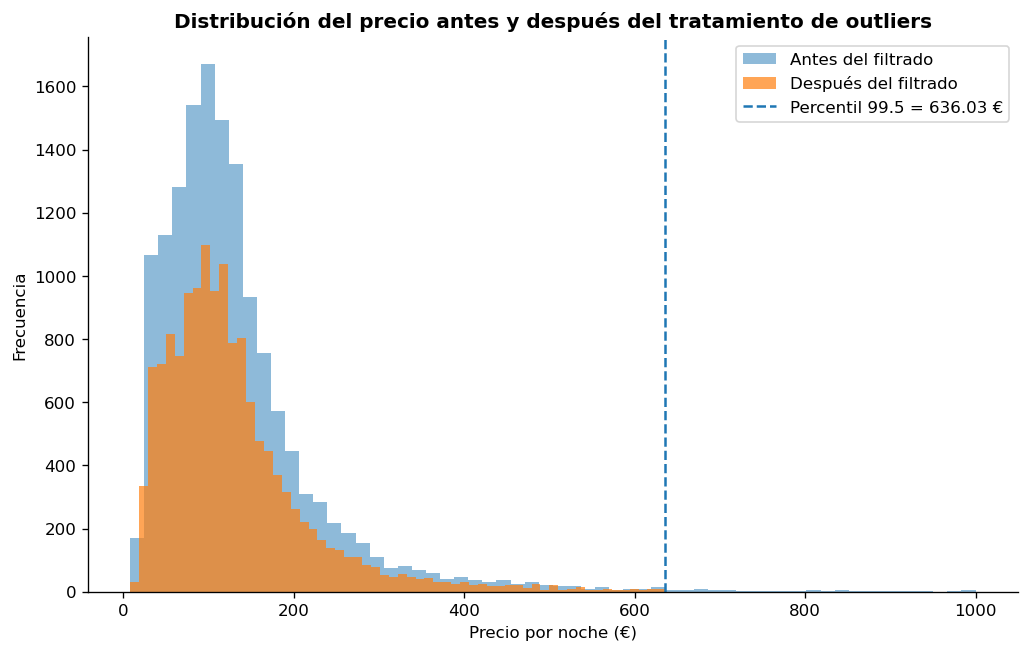

Valores nulos tras la limpieza:
host_since          88
host_tenure_days    88
bedrooms            23
beds                 9
dtype: int64


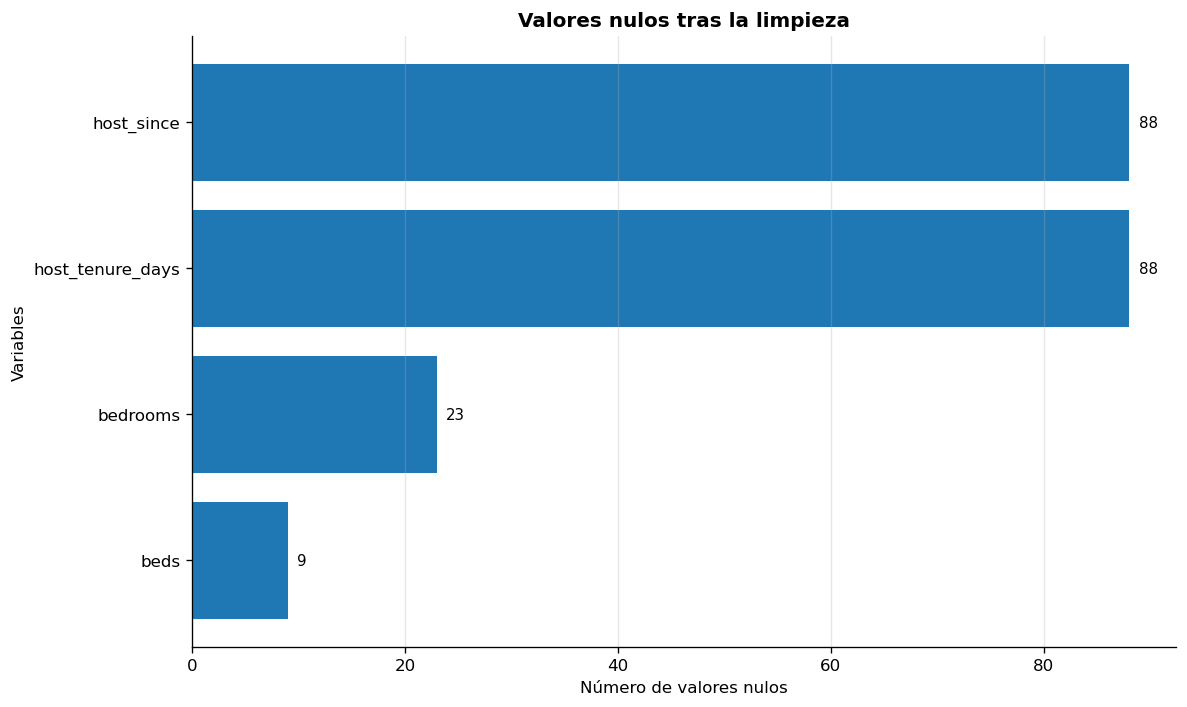

In [7]:

#eliminacion de outliers de precio (el 0,5% mñas extremo, eliminando el subjetivismo de lo considerado "caro" y "barato"):
upper_price = listings["price"].quantile(0.995)
listings = listings[listings["price"] <= upper_price]

# Eliminación de casos sin beneficio o sin ocupación (así me quedo solo con los activos):
listings = listings[
    (listings["estimated_occupancy_l365d"] > 0) &
    (listings["estimated_revenue_l365d"] > 0)
]

#Grafico de outliers:
#Carga del paquete de visualización:
import matplotlib.pyplot as plt
#Guardar una copia antes del filtrado: 
listings_pre_filtrado = listings.copy()
#Umbral percentil 99.5:
upper_price = listings_pre_filtrado["price"].quantile(0.995)
#Aplicar filtro:
listings_post_filtrado = listings_pre_filtrado[listings_pre_filtrado["price"] <= upper_price].copy()
#Visualización:
plt.figure(figsize=(10,6))
plt.hist(listings_pre_filtrado["price"].dropna(), bins=60, alpha=0.5, label="Antes del filtrado")
plt.hist(listings_post_filtrado["price"].dropna(), bins=60, alpha=0.7, label="Después del filtrado")
plt.axvline(upper_price, linestyle="--", label=f"Percentil 99.5 = {upper_price:.2f} €")
plt.title("Distribución del precio antes y después del tratamiento de outliers")
plt.xlabel("Precio por noche (€)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


#Gráfico de nulos tras limpieza: 
#1ºcomporbar nulos: 
null_counts_final = listings.isnull().sum()
null_counts_final = null_counts_final[null_counts_final > 0].sort_values(ascending=False)
print("Valores nulos tras la limpieza:")
print(null_counts_final)

#2ºVisualización: 
if len(null_counts_final) > 0:
    plt.figure(figsize=(10,6))
    bars = plt.barh(null_counts_final.index[::-1], null_counts_final.values[::-1])
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + max(null_counts_final) * 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{int(width)}",
            va="center",
            fontsize=9
        )
    plt.xlabel("Número de valores nulos")
    plt.ylabel("Variables")
    plt.title("Valores nulos tras la limpieza")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No quedan valores nulos en el dataset final.")


### 4.2 Justificación de decisiones de limpieza

In [8]:
# Justificación del umbral de outliers
upper_price_ref = listings['price'].quantile(0.995)
pct_eliminados  = (listings['price'] > upper_price_ref).mean() * 100

print("=== JUSTIFICACIÓN DEL TRATAMIENTO DE OUTLIERS ===")
print(f"  Umbral percentil 99,5 : {upper_price_ref:.2f} €/noche")
print(f"  Observaciones eliminadas: {pct_eliminados:.2f}% del total")
print()
print("  Criterio: se elimina el 0,5% superior de precios por constituir")
print("  valores extremos no representativos del mercado turístico estándar.")
print("  Este umbral es coherente con la literatura de precios hedónicos en")
print("  plataformas de alojamiento (Gibbs et al., 2018; Wang & Nicolau, 2017).")
print()

# Tabla resumen de la limpieza
resumen_limpieza = pd.DataFrame({
    'Variable': ['price', 'bathrooms', 'host_is_superhost', 'instant_bookable',
                 'amenities', 'host_since', 'estimated_occupancy_l365d'],
    'Problema detectado': [
        'Outliers extremos (cola derecha)',
        'Valores no numéricos / nulos',
        'Booleano como string (t/f)',
        'Booleano como string (t/f)',
        'JSON semiestructurado',
        'String → datetime',
        'Ceros (listings inactivos)'
    ],
    'Solución aplicada': [
        'Eliminación percentil 99,5%',
        'pd.to_numeric(errors=coerce) + mediana',
        'Mapeo a binario 0/1',
        'Mapeo a binario 0/1',
        'ast.literal_eval → count + has_wifi',
        'pd.to_datetime → tenure_days',
        'Filtro: occupancy > 0 AND revenue > 0'
    ]
})
print("Tabla 2. Resumen de decisiones de limpieza")
print(resumen_limpieza.to_string(index=False))
print("\nFuente: elaboración propia")

=== JUSTIFICACIÓN DEL TRATAMIENTO DE OUTLIERS ===
  Umbral percentil 99,5 : 636.03 €/noche
  Observaciones eliminadas: 0.50% del total

  Criterio: se elimina el 0,5% superior de precios por constituir
  valores extremos no representativos del mercado turístico estándar.
  Este umbral es coherente con la literatura de precios hedónicos en
  plataformas de alojamiento (Gibbs et al., 2018; Wang & Nicolau, 2017).

Tabla 2. Resumen de decisiones de limpieza
                 Variable               Problema detectado                      Solución aplicada
                    price Outliers extremos (cola derecha)            Eliminación percentil 99,5%
                bathrooms     Valores no numéricos / nulos pd.to_numeric(errors=coerce) + mediana
        host_is_superhost       Booleano como string (t/f)                    Mapeo a binario 0/1
         instant_bookable       Booleano como string (t/f)                    Mapeo a binario 0/1
                amenities            JSON semiestruc

5. Comprobaciones: 

       estimated_occupancy_l365d  occupancy_rate  estimated_revenue_l365d  \
count               14398.000000    14398.000000             14398.000000   
mean                  132.595986        0.363277             17059.262050   
std                    93.817391        0.257034             18636.423884   
min                     6.000000        0.016438                48.000000   
25%                    42.000000        0.115068              4080.000000   
50%                   120.000000        0.328767             11475.000000   
75%                   252.000000        0.690411             24225.000000   
max                   255.000000        0.698630            254490.000000   

          adr_check        revpar  
count  14398.000000  14398.000000  
mean     132.815252     46.737704  
std       98.458478     51.058696  
min        8.000000      0.131507  
25%       74.000000     11.178082  
50%      111.000000     31.438356  
75%      160.000000     66.369863  
max     1000.00000

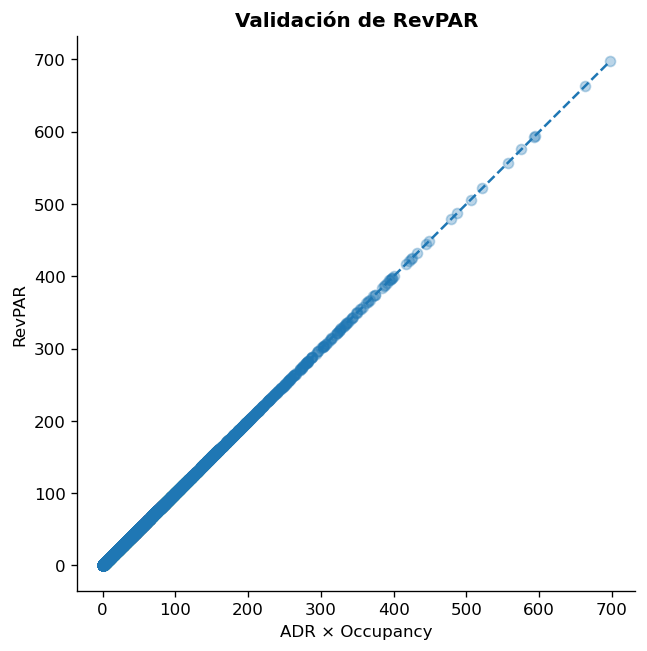

In [9]:
#Estadísticos de las variables: 
print(listings[["estimated_occupancy_l365d",
                "occupancy_rate",
                "estimated_revenue_l365d",
                "adr_check",
                "revpar"]].describe())

#Calculo de RevPAR para vericar que sea coherente (RevPAR = ADR * Occupancy Rate):
check = listings["adr_check"] * listings["occupancy_rate"]

#Tabla de comparación (RevPAR calculado vs RevPAR "recontruido"):
comparison = pd.DataFrame({
    "revpar": pd.to_numeric(listings["revpar"], errors="coerce"),
    "adr_x_occ": pd.to_numeric(check, errors="coerce")
})
print(comparison.head(10))

#Ver la diferencia entre ambos cálculos:
diff = comparison["revpar"] - comparison["adr_x_occ"]
diff = pd.to_numeric(diff, errors="coerce")
print(diff.describe())
print("Máxima diferencia absoluta:", diff.abs().max())
print(comparison.head(10))
print((comparison["revpar"] - comparison["adr_x_occ"]).describe())

#Visualización: 
plt.figure(figsize=(6,6))
plt.scatter(comparison["adr_x_occ"], comparison["revpar"], alpha=0.3)
plt.xlabel("ADR × Occupancy")
plt.ylabel("RevPAR")
plt.title("Validación de RevPAR")
plt.plot([0, comparison["revpar"].max()],
         [0, comparison["revpar"].max()],
         linestyle="--")
plt.show()

6. Output:

In [10]:
# ─────────────────────────────────────────────────────────────
# OUTPUT: guardar datasets procesados
# ─────────────────────────────────────────────────────────────
RUTA_OUTPUT = '/Users/luciagonzalezdavila/Documents/4º/TFG/Nuevas BBDD/'

listings.to_csv(RUTA_OUTPUT + 'listings_clean.csv', index=False)
print(f"✓ listings_clean.csv guardado ({listings.shape[0]:,} filas × {listings.shape[1]} cols)")
print(f"  Ruta: {RUTA_OUTPUT}listings_clean.csv")

✓ listings_clean.csv guardado (14,398 filas × 37 cols)
  Ruta: /Users/luciagonzalezdavila/Documents/4º/TFG/Nuevas BBDD/listings_clean.csv


---
## SECCIÓN A — Fuentes adicionales: `calendar.csv`, `reviews.csv`, `neighbourhoods.geojson`

In [11]:
# ── RUTAS — ajusta si tu carpeta es diferente ───────────────────────────
RUTA_BBDD   = '/Users/luciagonzalezdavila/Documents/4º/TFG/BBDD airbnb/'
RUTA_OUTPUT = '/Users/luciagonzalezdavila/Documents/4º/TFG/Nuevas BBDD/'

RUTA_CAL  = RUTA_BBDD + 'calendar.csv'
RUTA_REV  = RUTA_BBDD + 'reviews.csv'
RUTA_GEO  = RUTA_BBDD + 'neighbourhoods.geojson'

# Recargar listings_clean para asegurar que partimos del dataset limpio
df = pd.read_csv(RUTA_OUTPUT + 'listings_clean.csv')
print(f'listings_clean cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

listings_clean cargado: 14,398 filas × 37 columnas


### A.1 — `calendar.csv`: ocupación real y estacionalidad

In [12]:
print('Cargando calendar.csv (puede tardar 1-2 min)...')
cal = pd.read_csv(
    RUTA_CAL,
    usecols=['listing_id', 'date', 'available', 'price'],
    dtype={'listing_id': 'int64', 'available': 'str', 'price': 'str'}
)
print(f'Calendar: {cal.shape[0]:,} filas | {cal["listing_id"].nunique():,} listings únicos')

# Limpiar precio
cal['price_cal'] = (
    cal['price']
    .str.replace(r'[\$,]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

# Disponibilidad: 'f' = ocupado, 't' = libre
cal['occupied'] = (cal['available'] == 'f').astype(int)

# Fecha y mes
cal['date']   = pd.to_datetime(cal['date'])
cal['month']  = cal['date'].dt.month
cal['season'] = cal['month'].map({
    12:'Invierno', 1:'Invierno', 2:'Invierno',
    3:'Primavera', 4:'Primavera', 5:'Primavera',
    6:'Verano',    7:'Verano',    8:'Verano',
    9:'Otoño',    10:'Otoño',    11:'Otoño'
})

print(f'Rango de fechas: {cal["date"].min().date()} → {cal["date"].max().date()}')
cal.head(3)

Cargando calendar.csv (puede tardar 1-2 min)...
Calendar: 9,125,007 filas | 25,000 listings únicos
Rango de fechas: 2025-09-14 → 2026-09-14


,listing_id,date,available,price,price_cal,occupied,month,season
0,21853,2025-09-15,f,NaN,NaN,1,9,Otoño
1,21853,2025-09-16,f,NaN,NaN,1,9,Otoño
2,21853,2025-09-17,f,NaN,NaN,1,9,Otoño


In [13]:
# Variables agregadas por listing
cal_agg = cal.groupby('listing_id').agg(
    occupancy_rate_cal = ('occupied',   'mean'),
    price_mean_cal     = ('price_cal',  'mean'),
    price_std_cal      = ('price_cal',  'std'),
    days_occupied      = ('occupied',   'sum'),
).reset_index()

# Índice de estacionalidad: precio verano / precio invierno
seas = (
    cal.groupby(['listing_id','season'])['price_cal']
    .mean().unstack(fill_value=np.nan).reset_index()
)
seas.columns.name = None
if 'Verano' in seas.columns and 'Invierno' in seas.columns:
    seas['seasonality_index'] = seas['Verano'] / seas['Invierno']
    cal_agg = cal_agg.merge(seas[['listing_id','seasonality_index']], on='listing_id', how='left')

print(f'Variables calendar agregadas: {cal_agg.shape}')
cal_agg[['occupancy_rate_cal','price_mean_cal','price_std_cal','seasonality_index']].describe().round(3)

Variables calendar agregadas: (25000, 6)


,occupancy_rate_cal,price_mean_cal,price_std_cal,seasonality_index
count,25000.000,0.0,0.0,0.0
mean,0.535,NaN,NaN,NaN
std,0.368,NaN,NaN,NaN
min,0.000,NaN,NaN,NaN
25%,0.173,NaN,NaN,NaN
50%,0.526,NaN,NaN,NaN
75%,0.940,NaN,NaN,NaN
max,1.000,NaN,NaN,NaN


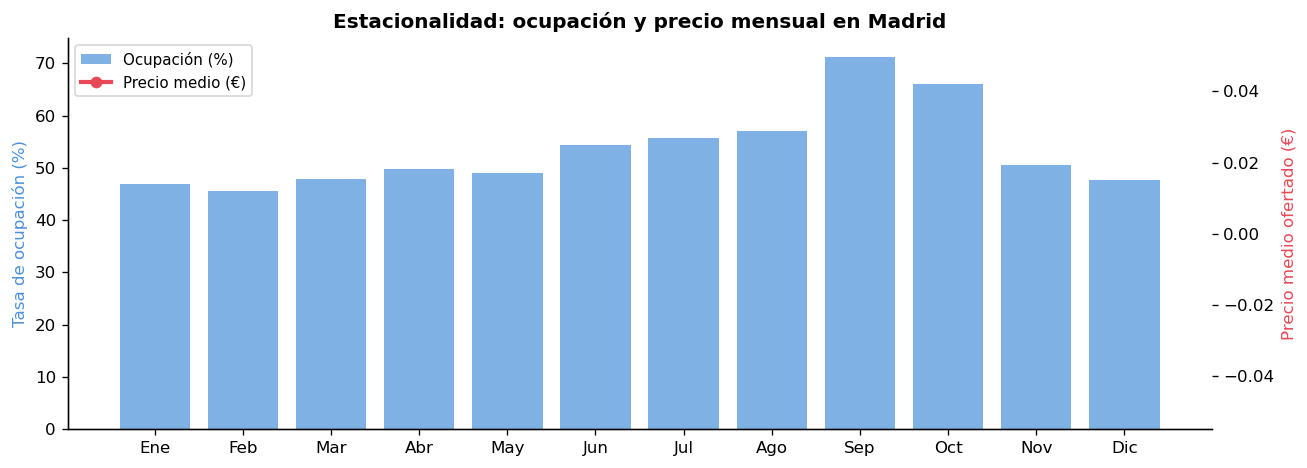

Fuente: elaboración propia a partir de Inside Airbnb — calendar.csv (sept. 2025)

Estadísticos mensuales:
mes  ocupacion_media  precio_medio
Ene         0.468523           NaN
Feb         0.455404           NaN
Mar         0.478826           NaN
Abr         0.497013           NaN
May         0.489804           NaN
Jun         0.542968           NaN
Jul         0.557623           NaN
Ago         0.571179           NaN
Sep         0.712548           NaN
Oct         0.659945           NaN
Nov         0.505831           NaN
Dic         0.477071           NaN


In [14]:
# Figura A1: Estacionalidad mensual — ocupación y precio
monthly = (
    cal.groupby('month')
    .agg(ocupacion_media=('occupied','mean'), precio_medio=('price_cal','mean'))
    .reset_index()
)
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax1 = plt.subplots(figsize=(11,4))
ax2 = ax1.twinx()
ax1.bar(monthly['month'], monthly['ocupacion_media']*100,
        color=COLOR_SEC, alpha=0.7, label='Ocupación (%)')
ax2.plot(monthly['month'], monthly['precio_medio'],
         color=COLOR_MAIN, linewidth=2.5, marker='o', label='Precio medio (€)')
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(MESES)
ax1.set_ylabel('Tasa de ocupación (%)', color=COLOR_SEC)
ax2.set_ylabel('Precio medio ofertado (€)', color=COLOR_MAIN)
ax1.set_title('Estacionalidad: ocupación y precio mensual en Madrid')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigA1_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente: elaboración propia a partir de Inside Airbnb — calendar.csv (sept. 2025)')
print()
print('Estadísticos mensuales:')
monthly['mes'] = MESES
print(monthly[['mes','ocupacion_media','precio_medio']].to_string(index=False))

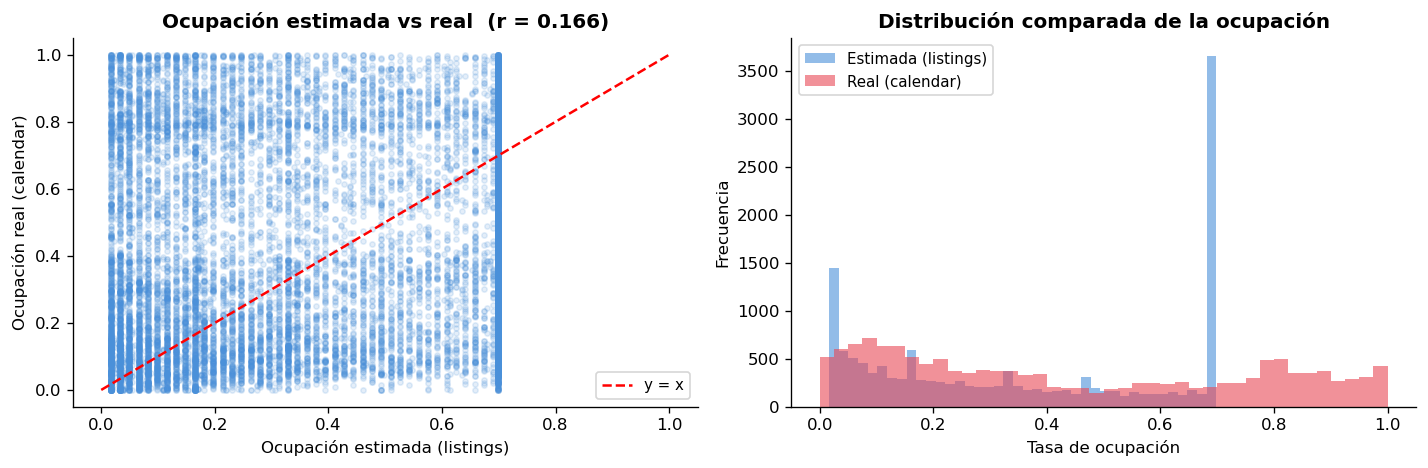

Correlación ocupación estimada vs real: r = 0.166
Cobertura: 14,398 listings (100.0%)

       occupancy_rate  occupancy_rate_cal
count       14398.000           14398.000
mean            0.363               0.437
std             0.257               0.316
min             0.016               0.000
25%             0.115               0.142
50%             0.329               0.359
75%             0.690               0.756
max             0.699               1.000


In [15]:
# Figura A2-A3: ocupación estimada (listings) vs ocupación real (calendar)
id_col = 'listing_id' if 'listing_id' in df.columns else 'id'
df[id_col] = df[id_col].astype('int64')
cal_agg['listing_id'] = cal_agg['listing_id'].astype('int64')

comp = df[[id_col,'occupancy_rate']].merge(
    cal_agg[['listing_id','occupancy_rate_cal']],
    left_on=id_col, right_on='listing_id', how='inner'
).dropna()
corr_occ = comp[['occupancy_rate','occupancy_rate_cal']].corr().iloc[0,1]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].scatter(comp['occupancy_rate'], comp['occupancy_rate_cal'],
                alpha=0.15, s=10, color=COLOR_SEC)
axes[0].plot([0,1],[0,1],'r--', linewidth=1.5, label='y = x')
axes[0].set_xlabel('Ocupación estimada (listings)')
axes[0].set_ylabel('Ocupación real (calendar)')
axes[0].set_title(f'Ocupación estimada vs real  (r = {corr_occ:.3f})')
axes[0].legend(fontsize=9)

axes[1].hist(comp['occupancy_rate'],     bins=40, alpha=0.6, label='Estimada (listings)', color=COLOR_SEC)
axes[1].hist(comp['occupancy_rate_cal'], bins=40, alpha=0.6, label='Real (calendar)',     color=COLOR_MAIN)
axes[1].set_xlabel('Tasa de ocupación')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución comparada de la ocupación')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigA2A3_ocupacion_comparada.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlación ocupación estimada vs real: r = {corr_occ:.3f}')
print(f'Cobertura: {len(comp):,} listings ({len(comp)/len(df)*100:.1f}%)')
print()
print(comp[['occupancy_rate','occupancy_rate_cal']].describe().round(3))

### A.2 — `reviews.csv`: actividad reciente y antigüedad del listing

In [16]:
print('Cargando reviews.csv...')
rev = pd.read_csv(
    RUTA_REV,
    usecols=['listing_id', 'date'],
    parse_dates=['date']
)
print(f'Reviews: {rev.shape[0]:,} reseñas | {rev["listing_id"].nunique():,} listings únicos')
print(f'Rango: {rev["date"].min().date()} → {rev["date"].max().date()}')

FECHA_REF = pd.Timestamp('2025-09-14')
HACE_12M  = FECHA_REF - pd.DateOffset(months=12)

Cargando reviews.csv...
Reviews: 1,275,992 reseñas | 19,853 listings únicos
Rango: 2010-07-06 → 2025-09-14


In [17]:
# Variables agregadas por listing
rev_agg = rev.groupby('listing_id').agg(
    total_reviews_hist = ('date','count'),
    primera_review     = ('date','min'),
    ultima_review      = ('date','max'),
).reset_index()

# Reviews últimos 12 meses
rev_12m = (rev[rev['date'] >= HACE_12M]
           .groupby('listing_id').size()
           .reset_index(name='reviews_last_12m'))
rev_agg = rev_agg.merge(rev_12m, on='listing_id', how='left')
rev_agg['reviews_last_12m'] = rev_agg['reviews_last_12m'].fillna(0).astype(int)

# Días desde última reseña
rev_agg['days_since_last_review'] = (FECHA_REF - rev_agg['ultima_review']).dt.days

# Antigüedad del listing
rev_agg['listing_age_days'] = (FECHA_REF - rev_agg['primera_review']).dt.days

# Listing activo: reseña en últimos 6 meses
rev_agg['listing_activo'] = (rev_agg['days_since_last_review'] <= 180).astype(int)

rev_agg = rev_agg[['listing_id','total_reviews_hist','reviews_last_12m',
                   'days_since_last_review','listing_age_days','listing_activo']]

print(f'Variables reviews agregadas: {rev_agg.shape}')
rev_agg.describe().round(1)

Variables reviews agregadas: (19853, 6)


,listing_id,total_reviews_hist,reviews_last_12m,days_since_last_review,listing_age_days,listing_activo
count,1.985300e+04,19853.0,19853.0,19853.0,19853.0,19853.0
mean,6.912223e+17,64.3,18.0,320.6,1208.7,0.7
std,5.587122e+17,103.9,24.3,679.2,1094.2,0.4
min,2.185300e+04,1.0,0.0,0.0,0.0,0.0
25%,3.951944e+07,5.0,1.0,14.0,357.0,0.0
50%,8.579087e+17,22.0,8.0,48.0,807.0,1.0
75%,1.189813e+18,76.0,27.0,207.0,2034.0,1.0
max,1.507409e+18,1184.0,592.0,4789.0,5549.0,1.0


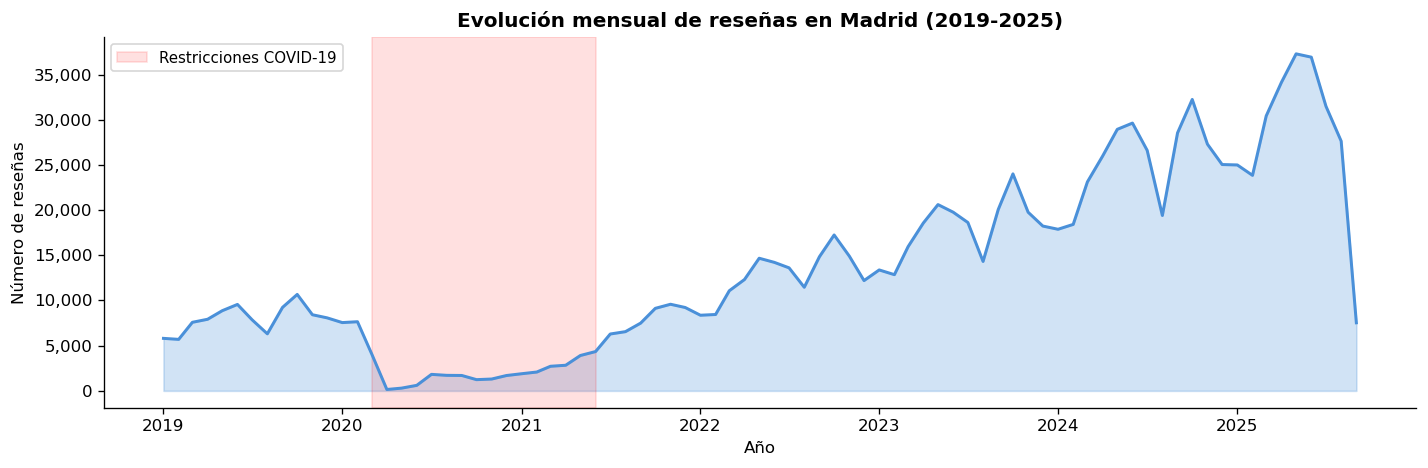

Fuente: elaboración propia a partir de Inside Airbnb — reviews.csv (sept. 2025)

Mes con más actividad: 2025-05 (37,295 reseñas)
Media mensual pre-COVID  (hasta feb 2020): 7,943
Media mensual post-COVID (desde ene 2022): 20,599
Recuperación: 259.3% del nivel pre-pandemia


In [18]:
# Figura B1: Evolución mensual del mercado 2019-2025
rev['year_month'] = rev['date'].dt.to_period('M')
rev_monthly = (rev[rev['date'] >= '2019-01-01']
               .groupby('year_month').size()
               .reset_index(name='n_reviews'))
rev_monthly['fecha'] = rev_monthly['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12,4))
ax.fill_between(rev_monthly['fecha'], rev_monthly['n_reviews'], alpha=0.25, color=COLOR_SEC)
ax.plot(rev_monthly['fecha'], rev_monthly['n_reviews'], color=COLOR_SEC, linewidth=1.8)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.12, color='red', label='Restricciones COVID-19')
ax.set_title('Evolución mensual de reseñas en Madrid (2019-2025)')
ax.set_ylabel('Número de reseñas')
ax.set_xlabel('Año')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigB1_evolucion_reviews.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente: elaboración propia a partir de Inside Airbnb — reviews.csv (sept. 2025)')

# Estadísticos pre/post COVID
pre  = rev_monthly[rev_monthly['fecha'] < '2020-03-01']['n_reviews'].mean()
post = rev_monthly[rev_monthly['fecha'] >= '2022-01-01']['n_reviews'].mean()
pico = rev_monthly.loc[rev_monthly['n_reviews'].idxmax()]
print(f'\nMes con más actividad: {pico["year_month"]} ({pico["n_reviews"]:,} reseñas)')
print(f'Media mensual pre-COVID  (hasta feb 2020): {pre:,.0f}')
print(f'Media mensual post-COVID (desde ene 2022): {post:,.0f}')
print(f'Recuperación: {post/pre*100:.1f}% del nivel pre-pandemia')

### A.3 — `neighbourhoods.geojson`: mapas coropléticos

In [19]:
gdf = gpd.read_file(RUTA_GEO)
print(f'GeoJSON cargado: {gdf.shape[0]} barrios')
print(f'Columnas: {gdf.columns.tolist()}')

# Estadísticos por barrio
barrio_stats = df.groupby('neighbourhood_cleansed').agg(
    precio_mediano  = ('price',          'median'),
    revpar_mediano  = ('revpar',         'median'),
    ocupacion_media = ('occupancy_rate', 'mean'),
    n_listings      = (id_col,          'count'),
).reset_index()

# Merge con geojson (detectar nombre de columna automáticamente)
geo_col = 'neighbourhood' if 'neighbourhood' in gdf.columns else gdf.columns[1]
gdf_m = gdf.merge(barrio_stats, left_on=geo_col,
                  right_on='neighbourhood_cleansed', how='left')
print(f'Barrios con datos: {gdf_m["precio_mediano"].notna().sum()}/{len(gdf_m)}')

GeoJSON cargado: 128 barrios
Columnas: ['neighbourhood', 'neighbourhood_group', 'geometry']
Barrios con datos: 126/128


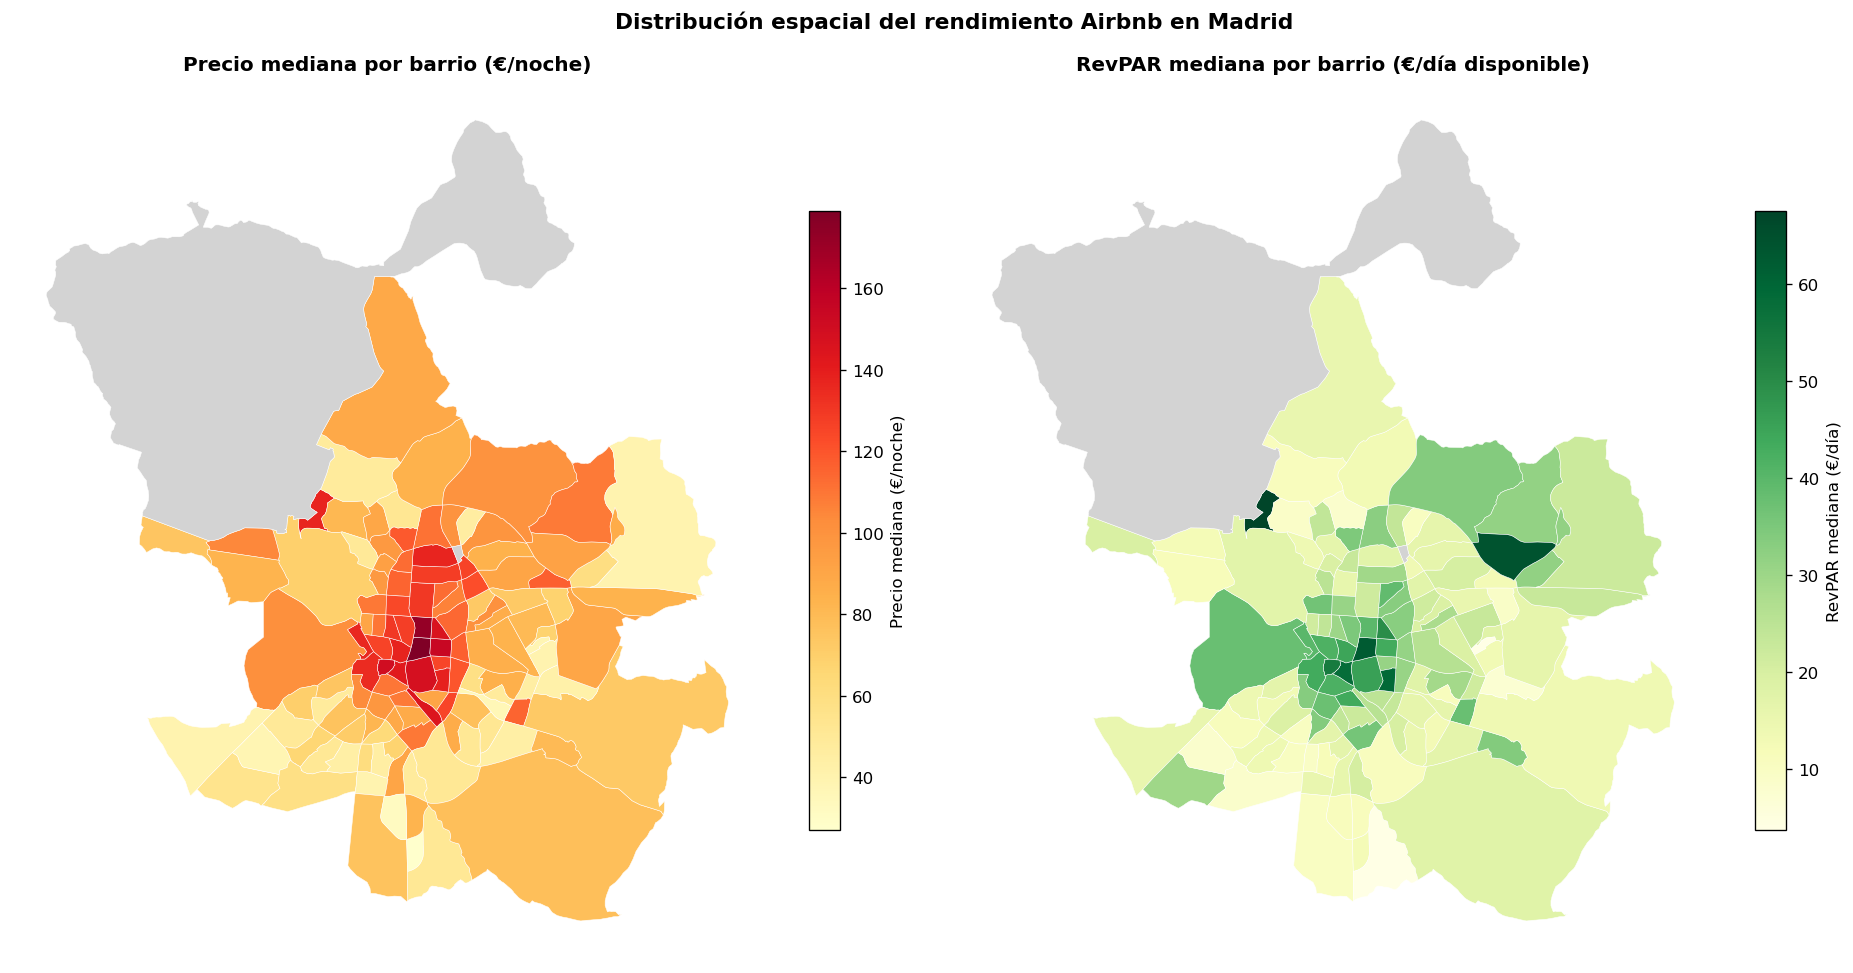

Fuente: elaboración propia a partir de Inside Airbnb — listings_clean + neighbourhoods.geojson

Top 10 barrios por RevPAR mediano:
neighbourhood_cleansed  revpar_mediano  precio_mediano  n_listings
         Fuentelareina       67.561644           137.0           3
            Corralejos       64.273973            92.0           7
             Recoletos       62.375342           179.0         178
            Niño Jesús       59.178082           138.5          44
                Cortes       58.143836           142.0         692
                   Sol       54.279452           150.0         893
                 Lista       49.709589           146.0         115
             Jerónimos       45.760274           148.0          66
              Justicia       44.778082           138.0         720
       Palos de Moguer       43.668493           108.5         248


In [20]:
# Figura C1-C2: Mapas coropléticos precio y RevPAR
fig, axes = plt.subplots(1, 2, figsize=(16,8))

gdf_m.plot(column='precio_mediano', ax=axes[0], cmap='YlOrRd', legend=True,
           legend_kwds={'label':'Precio mediana (€/noche)','shrink':0.7},
           missing_kwds={'color':'lightgrey'}, edgecolor='white', linewidth=0.3)
axes[0].set_title('Precio mediana por barrio (€/noche)')
axes[0].axis('off')

gdf_m.plot(column='revpar_mediano', ax=axes[1], cmap='YlGn', legend=True,
           legend_kwds={'label':'RevPAR mediana (€/día)','shrink':0.7},
           missing_kwds={'color':'lightgrey'}, edgecolor='white', linewidth=0.3)
axes[1].set_title('RevPAR mediana por barrio (€/día disponible)')
axes[1].axis('off')

plt.suptitle('Distribución espacial del rendimiento Airbnb en Madrid',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigC1C2_mapas_barrios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente: elaboración propia a partir de Inside Airbnb — listings_clean + neighbourhoods.geojson')

print('\nTop 10 barrios por RevPAR mediano:')
print(barrio_stats.nlargest(10,'revpar_mediano')
      [['neighbourhood_cleansed','revpar_mediano','precio_mediano','n_listings']]
      .to_string(index=False))

### A.4 — Dataset enriquecido `listings_enriched`

In [21]:
# Merge de las tres fuentes sobre listings_clean
rev_agg['listing_id'] = rev_agg['listing_id'].astype('int64')

enriched = (
    df
    .merge(cal_agg, left_on=id_col, right_on='listing_id', how='left', suffixes=('','_cal'))
    .merge(rev_agg, left_on=id_col, right_on='listing_id', how='left', suffixes=('','_rev'))
)
# Eliminar columnas listing_id duplicadas del merge
enriched = enriched.drop(
    columns=[c for c in enriched.columns if c.startswith('listing_id') and c != id_col],
    errors='ignore'
)

print(f'listings_enriched: {enriched.shape[0]:,} filas × {enriched.shape[1]} columnas')
print('\nCobertura de nuevas variables:')
for col in ['occupancy_rate_cal','price_mean_cal','seasonality_index',
            'reviews_last_12m','listing_age_days']:
    if col in enriched.columns:
        n = enriched[col].notna().sum()
        print(f'  {col:<30}: {n:,} ({n/len(enriched)*100:.1f}%)')

enriched.to_csv(RUTA_OUTPUT + 'listings_enriched.csv', index=False)
print(f'\nlisting_enriched.csv guardado en {RUTA_OUTPUT}')

listings_enriched: 14,398 filas × 47 columnas

Cobertura de nuevas variables:
  occupancy_rate_cal            : 14,398 (100.0%)
  price_mean_cal                : 0 (0.0%)
  seasonality_index             : 0 (0.0%)
  reviews_last_12m              : 14,398 (100.0%)
  listing_age_days              : 14,398 (100.0%)

listing_enriched.csv guardado en /Users/luciagonzalezdavila/Documents/4º/TFG/Nuevas BBDD/


7. Visualización:

### 7. Análisis Exploratorio de Datos (EDA)

In [22]:
# 7.1 ESTADÍSTICOS DESCRIPTIVOS FINALES (post-limpieza)
vars_final = ['price', 'occupancy_rate', 'revpar', 'accommodates',
              'bedrooms', 'amenities_count', 'review_scores_rating',
              'host_tenure_days']
vars_presentes = [v for v in vars_final if v in listings.columns]

desc_final = listings[vars_presentes].describe().T
desc_final = desc_final[['count','mean','std','50%','25%','75%']].round(2)
desc_final.columns = ['N', 'Media', 'Desv. típica', 'Mediana', 'P25', 'P75']
print("Estadísticos descriptivos del dataset final")
print(desc_final.to_string())
print("\nFuente: elaboración propia a partir de Inside Airbnb (sept. 2025)")

Estadísticos descriptivos del dataset final
                            N    Media  Desv. típica  Mediana      P25      P75
price                 14398.0   132.82         98.46   111.00    74.00   160.00
occupancy_rate        14398.0     0.36          0.26     0.33     0.12     0.69
revpar                14398.0    46.74         51.06    31.44    11.18    66.37
accommodates          14398.0     3.42          1.96     3.00     2.00     4.00
bedrooms              14375.0     1.36          0.91     1.00     1.00     2.00
amenities_count       14398.0    29.65         12.34    30.00    22.00    38.00
review_scores_rating  14398.0     4.64          0.44     4.75     4.55     4.89
host_tenure_days      14310.0  2461.59       1397.20  2454.00  1250.00  3626.75

Fuente: elaboración propia a partir de Inside Airbnb (sept. 2025)


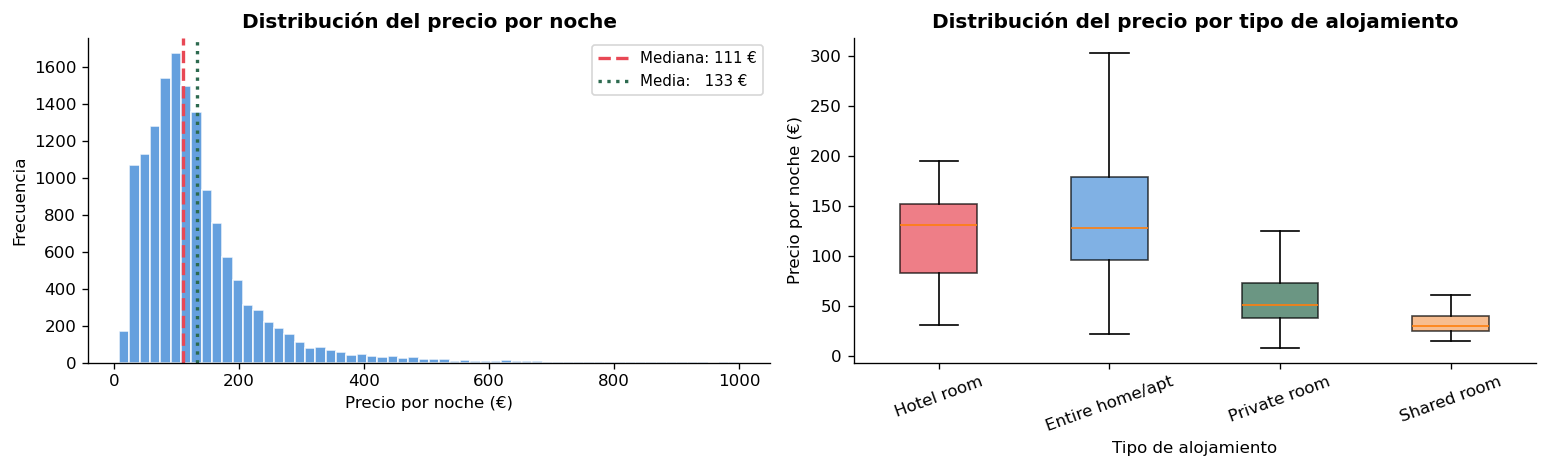

Fuente: elaboración propia


In [23]:
# 7.2 DISTRIBUCIÓN DE PRECIOS (mejorado)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma precio
axes[0].hist(listings['price'].dropna(), bins=60, color=COLOR_SEC, alpha=0.85, edgecolor='white')
axes[0].axvline(listings['price'].median(), color=COLOR_MAIN, linewidth=2,
                linestyle='--', label=f"Mediana: {listings['price'].median():.0f} €")
axes[0].axvline(listings['price'].mean(),   color=COLOR_TERC, linewidth=2,
                linestyle=':', label=f"Media:   {listings['price'].mean():.0f} €")
axes[0].set_xlabel("Precio por noche (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución del precio por noche")
axes[0].legend(fontsize=9)

# Boxplot por tipo de habitación
room_order = listings.groupby('room_type')['price'].median().sort_values(ascending=False).index
data_box = [listings[listings['room_type']==rt]['price'].dropna() for rt in room_order]
bp = axes[1].boxplot(data_box, labels=room_order, patch_artist=True, showfliers=False, vert=True)
colors_box = [COLOR_MAIN, COLOR_SEC, COLOR_TERC, '#F4A261']
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_xlabel("Tipo de alojamiento")
axes[1].set_ylabel("Precio por noche (€)")
axes[1].set_title("Distribución del precio por tipo de alojamiento")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('Fig1_2_precio_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fuente: elaboración propia")

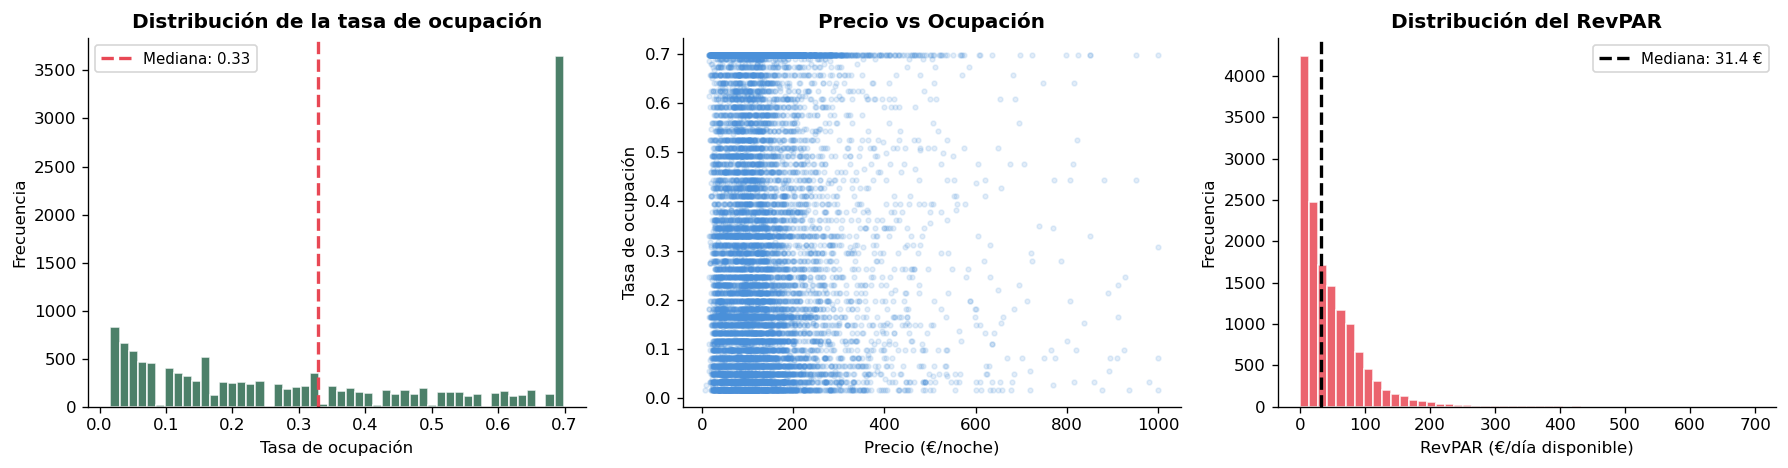

Fuente: elaboración propia


In [24]:
# 7.3 OCUPACIÓN Y REVPAR
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución ocupación
axes[0].hist(listings['occupancy_rate'].dropna(), bins=50, color=COLOR_TERC, alpha=0.85, edgecolor='white')
axes[0].axvline(listings['occupancy_rate'].median(), color=COLOR_MAIN, linewidth=2,
                linestyle='--', label=f"Mediana: {listings['occupancy_rate'].median():.2f}")
axes[0].set_xlabel("Tasa de ocupación")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de la tasa de ocupación")
axes[0].legend(fontsize=9)

# Precio vs Ocupación (scatter)
axes[1].scatter(listings['price'], listings['occupancy_rate'], alpha=0.15, s=8, color=COLOR_SEC)
axes[1].set_xlabel("Precio (€/noche)")
axes[1].set_ylabel("Tasa de ocupación")
axes[1].set_title("Precio vs Ocupación")

# Distribución RevPAR
axes[2].hist(listings['revpar'].dropna(), bins=50, color=COLOR_MAIN, alpha=0.85, edgecolor='white')
axes[2].axvline(listings['revpar'].median(), color='black', linewidth=2,
                linestyle='--', label=f"Mediana: {listings['revpar'].median():.1f} €")
axes[2].set_xlabel("RevPAR (€/día disponible)")
axes[2].set_ylabel("Frecuencia")
axes[2].set_title("Distribución del RevPAR")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('Fig3_5_ocupacion_revpar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fuente: elaboración propia")

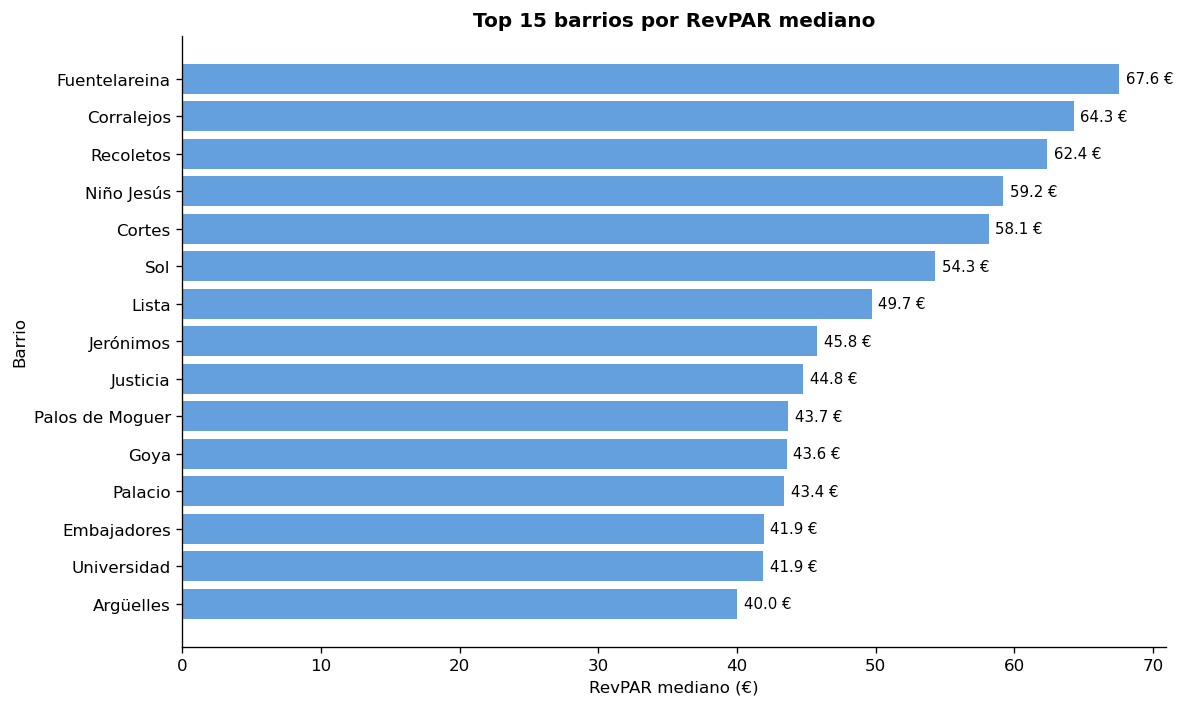

Fuente: elaboración propia


In [25]:
# 7.4 TOP 15 BARRIOS POR REVPAR (mediana) — mejorado
revpar_barrio = (listings.groupby('neighbourhood_cleansed')['revpar']
                 .median().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(revpar_barrio.index[::-1], revpar_barrio.values[::-1],
               color=COLOR_SEC, alpha=0.85)
ax.bar_label(bars, fmt='%.1f €', padding=4, fontsize=9)
ax.set_xlabel('RevPAR mediano (€)')
ax.set_ylabel('Barrio')
ax.set_title('Top 15 barrios por RevPAR mediano')
plt.tight_layout()
plt.savefig('Fig6_top15_barrios.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fuente: elaboración propia")

# Nota: se usa mediana (y no media) para mitigar el efecto de outliers extremos
# en barrios con pocos listings pero precios muy elevados.

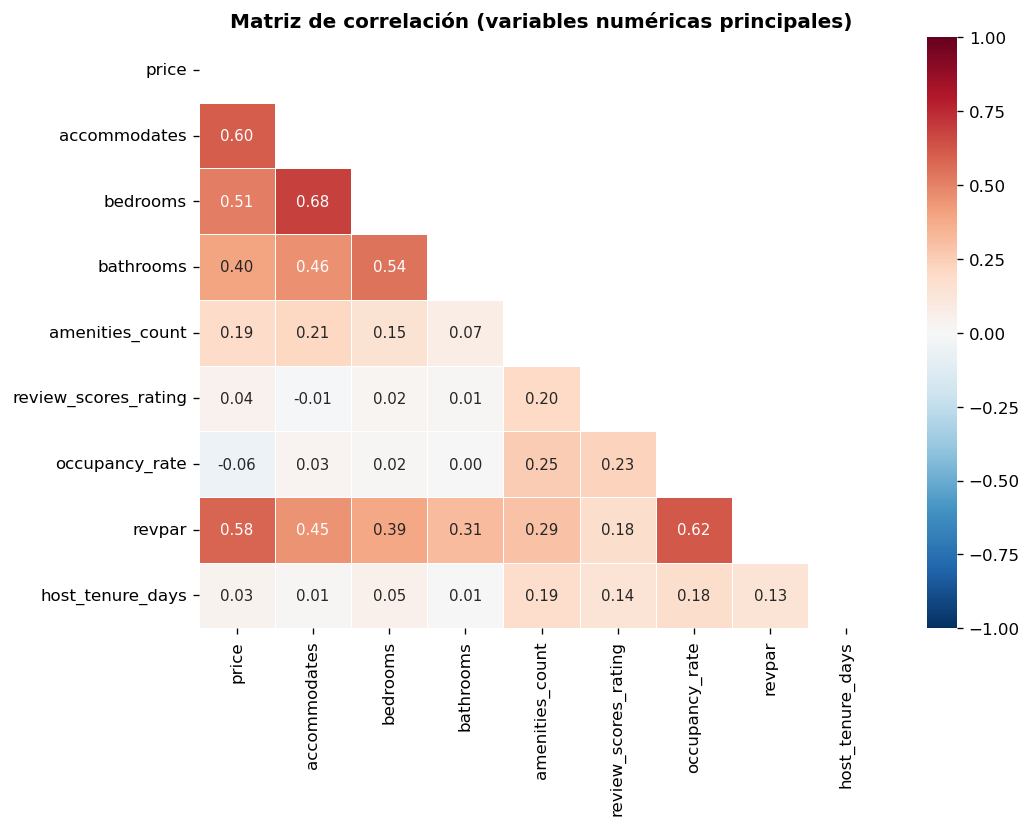

Fuente: elaboración propia

Correlaciones más relevantes con precio:
accommodates            0.604596
revpar                  0.582689
bedrooms                0.510488
bathrooms               0.399817
amenities_count         0.191458
review_scores_rating    0.043478
host_tenure_days        0.034846
occupancy_rate         -0.059710


In [26]:
# 7.5 MATRIZ DE CORRELACIÓN (mejorada con heatmap seaborn)
corr_vars = ['price', 'accommodates', 'bedrooms', 'bathrooms',
             'amenities_count', 'review_scores_rating',
             'occupancy_rate', 'revpar', 'host_tenure_days']
corr_vars = [v for v in corr_vars if v in listings.columns]
corr = listings[corr_vars].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación (variables numéricas principales)')
plt.tight_layout()
plt.savefig('Fig7_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fuente: elaboración propia")
print()
print("Correlaciones más relevantes con precio:")
print(corr['price'].sort_values(ascending=False).drop('price').to_string())

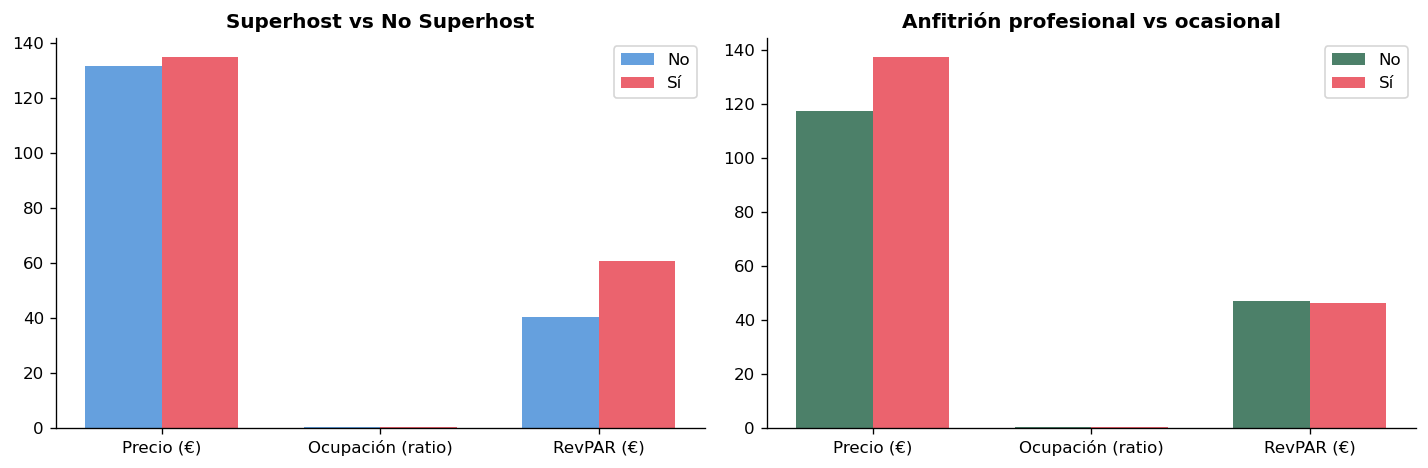

Fuente: elaboración propia


In [28]:
# 7.6 SUPERHOST Y HOST PROFESIONAL
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, var, titulo, palette in zip(
    axes,
    ['host_is_superhost', 'professional_host'],
    ['Superhost vs No Superhost', 'Anfitrión profesional vs ocasional'],
    [[COLOR_SEC, COLOR_MAIN], [COLOR_TERC, COLOR_MAIN]]
):
    grupos = listings.groupby(var)[['price', 'occupancy_rate', 'revpar']].mean().round(2)
    etiquetas = ['No', 'Sí']
    x = np.arange(3)
    width = 0.35
    bars1 = ax.bar(x - width/2, grupos.iloc[0], width, label=etiquetas[0], color=palette[0], alpha=0.85)
    bars2 = ax.bar(x + width/2, grupos.iloc[1], width, label=etiquetas[1], color=palette[1], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['Precio (€)', 'Ocupación (ratio)', 'RevPAR (€)'])
    ax.set_title(titulo)  # ← simplemente el título, sin numeración
    ax.legend()

plt.tight_layout()
plt.savefig('Fig_superhost_profesional.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fuente: elaboración propia")

8. Modelado:

## 8. Modelado

In [29]:
# ─────────────────────────────────────────────────────────────
# 8.0 CARGAR LISTINGS_ENRICHED COMO BASE DE LOS MODELOS
# listings_enriched = listings_clean + variables de calendar
# (occupancy_rate_cal, price_mean_cal, seasonality_index)
# + variables de reviews (reviews_last_12m, listing_age_days)
# ─────────────────────────────────────────────────────────────
enriched = pd.read_csv(RUTA_OUTPUT + 'listings_enriched.csv')
print(f'listings_enriched cargado: {enriched.shape[0]:,} filas × {enriched.shape[1]} columnas')

# Columnas nuevas disponibles
nuevas = ['occupancy_rate_cal','price_mean_cal','price_std_cal',
          'seasonality_index','reviews_last_12m','listing_age_days','listing_activo']
print('\nNuevas variables del enriquecimiento:')
for c in nuevas:
    if c in enriched.columns:
        n = enriched[c].notna().sum()
        print(f'  {c:<30}: {n:,} valores ({n/len(enriched)*100:.1f}%)')

listings_enriched cargado: 14,398 filas × 47 columnas

Nuevas variables del enriquecimiento:
  occupancy_rate_cal            : 14,398 valores (100.0%)
  price_mean_cal                : 0 valores (0.0%)
  price_std_cal                 : 0 valores (0.0%)
  seasonality_index             : 0 valores (0.0%)
  reviews_last_12m              : 14,398 valores (100.0%)
  listing_age_days              : 14,398 valores (100.0%)
  listing_activo                : 14,398 valores (100.0%)


In [30]:
# 8.1 PREPARACIONES PREVIAS
enriched = enriched.copy()

# Crear log_price (no existe en enriched, hay que calcularlo)
enriched['log_price'] = np.where(enriched['price'] > 0, np.log(enriched['price']), np.nan)

# Verificar qué variables nuevas tienen cobertura real
print("Cobertura de variables enriquecidas:")
for col in ['occupancy_rate_cal', 'seasonality_index', 'reviews_last_12m',
            'listing_age_days', 'price_mean_cal', 'price_std_cal']:
    if col in enriched.columns:
        n = enriched[col].notna().sum()
        print(f"  {col:<30}: {n:,} ({n/len(enriched)*100:.1f}%)")

# Base Modelo 1 (precio) — solo variables con cobertura
model_data_price = enriched[[
    'price', 'accommodates', 'bedrooms', 'amenities_count', 'has_wifi',
    'room_type', 'neighbourhood_cleansed', 'review_scores_rating',
    'host_is_superhost', 'reviews_last_12m', 'listing_age_days'
]].dropna().copy()
print(f'\nBase Modelo 1 (precio): {model_data_price.shape[0]:,} observaciones')

# Base Modelo 2 (ocupación real) — sin seasonality_index (cobertura 0%)
occ_data = enriched[enriched['price'] > 0].copy()
occ_data['log_price'] = np.log(occ_data['price'])

model_data_occ = occ_data[[
    'occupancy_rate_cal', 'log_price', 'accommodates', 'bedrooms',
    'amenities_count', 'has_wifi', 'bathrooms_missing',
    'room_type', 'neighbourhood_cleansed', 'review_scores_rating',
    'host_is_superhost', 'reviews_last_12m'
]].dropna().copy()
print(f'Base Modelo 2 (ocupación real): {model_data_occ.shape[0]:,} observaciones')

Cobertura de variables enriquecidas:
  occupancy_rate_cal            : 14,398 (100.0%)
  seasonality_index             : 0 (0.0%)
  reviews_last_12m              : 14,398 (100.0%)
  listing_age_days              : 14,398 (100.0%)
  price_mean_cal                : 0 (0.0%)
  price_std_cal                 : 0 (0.0%)

Base Modelo 1 (precio): 14,375 observaciones
Base Modelo 2 (ocupación real): 14,375 observaciones


RMSE precio: 69.257
MAE  precio: 42.083
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     106.9
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        00:48:00   Log-Likelihood:                -81316.
No. Observations:               14375   AIC:                         1.629e+05
Df Residuals:                   14238   BIC:                         1.639e+05
Df Model:                         136                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

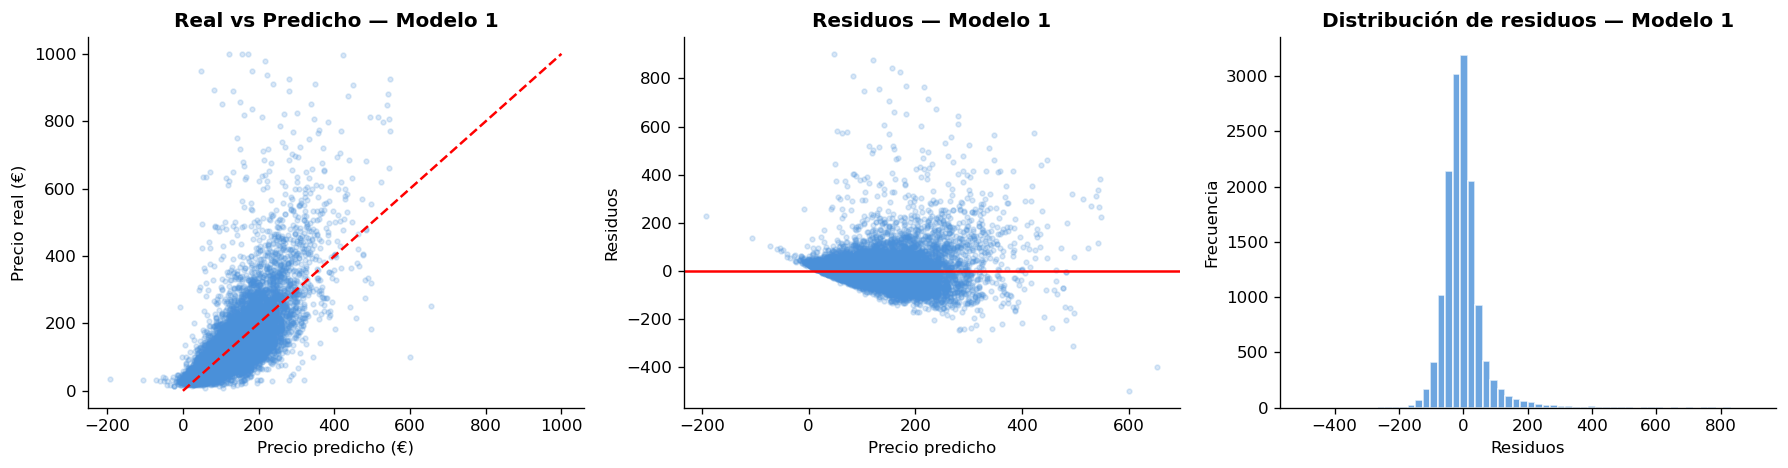

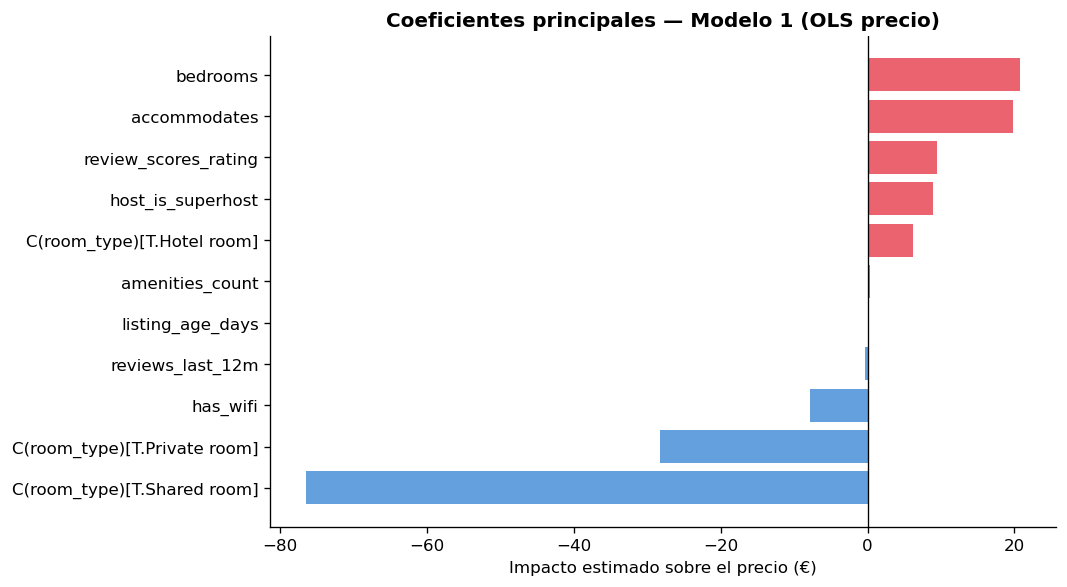

Fuente: elaboración propia


In [31]:
# 8.2 MODELO 1 — PRECIO (HEDONIC PRICING ENRIQUECIDO)
# Novedad respecto a la versión base: se añaden reviews_last_12m
# (proxy de demanda reciente, fuente: reviews.csv) y listing_age_days
# (antigüedad del listing, fuente: reviews.csv) como determinantes del precio.

model_price = smf.ols(
    formula="""
    price ~ accommodates + bedrooms + amenities_count + has_wifi +
            C(room_type) + C(neighbourhood_cleansed) +
            review_scores_rating + host_is_superhost +
            reviews_last_12m + listing_age_days
    """,
    data=model_data_price
).fit()

y_true_price = model_data_price['price']
y_pred_price = model_price.fittedvalues

rmse_price = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
mae_price  = mean_absolute_error(y_true_price, y_pred_price)

print('RMSE precio:', round(rmse_price, 3))
print('MAE  precio:', round(mae_price, 3))
print(model_price.summary())

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_price, y_true_price, alpha=0.2, s=8, color=COLOR_SEC)
lim = max(float(y_true_price.max()), float(y_pred_price.max()))
axes[0].plot([0,lim],[0,lim],'r--', linewidth=1.5)
axes[0].set_xlabel('Precio predicho (€)')
axes[0].set_ylabel('Precio real (€)')
axes[0].set_title('Real vs Predicho — Modelo 1')

residuals = y_true_price - y_pred_price
axes[1].scatter(y_pred_price, residuals, alpha=0.2, s=8, color=COLOR_SEC)
axes[1].axhline(0, color='red', linewidth=1.5)
axes[1].set_xlabel('Precio predicho')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos — Modelo 1')

axes[2].hist(residuals, bins=60, color=COLOR_SEC, alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Residuos')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de residuos — Modelo 1')

plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigM1_precio_ols.png', dpi=150, bbox_inches='tight')
plt.show()

# Coeficientes clave
variables_clave = [
    'accommodates', 'bedrooms', 'amenities_count', 'has_wifi',
    'review_scores_rating', 'host_is_superhost',
    'reviews_last_12m', 'listing_age_days',
    'C(room_type)[T.Private room]',
    'C(room_type)[T.Shared room]',
    'C(room_type)[T.Hotel room]'
]
coefs = model_price.params
coefs_filtrados = coefs[coefs.index.isin(variables_clave)].sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [COLOR_MAIN if v >= 0 else COLOR_SEC for v in coefs_filtrados.values]
ax.barh(coefs_filtrados.index, coefs_filtrados.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Impacto estimado sobre el precio (€)')
ax.set_title('Coeficientes principales — Modelo 1 (OLS precio)')
plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigM1d_coefs_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente: elaboración propia')

In [32]:
# DIAGNÓSTICO — ejecutar antes del Modelo 2
print("Filas en model_data_occ:", len(model_data_occ))
print()
print("Nulos por variable:")
print(model_data_occ.isna().sum().to_string())
print()
print("Filas con al menos un nulo:", model_data_occ.isna().any(axis=1).sum())

Filas en model_data_occ: 14375

Nulos por variable:
occupancy_rate_cal        0
log_price                 0
accommodates              0
bedrooms                  0
amenities_count           0
has_wifi                  0
bathrooms_missing         0
room_type                 0
neighbourhood_cleansed    0
review_scores_rating      0
host_is_superhost         0
reviews_last_12m          0

Filas con al menos un nulo: 0


RMSE ocupación real: 0.3041
MAE  ocupación real: 0.2682
                            OLS Regression Results                            
Dep. Variable:     occupancy_rate_cal   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     8.051
Date:                Sun, 24 May 2026   Prob (F-statistic):          7.80e-144
Time:                        00:48:17   Log-Likelihood:                -3284.6
No. Observations:               14375   AIC:                             6845.
Df Residuals:                   14237   BIC:                             7890.
Df Model:                         137                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

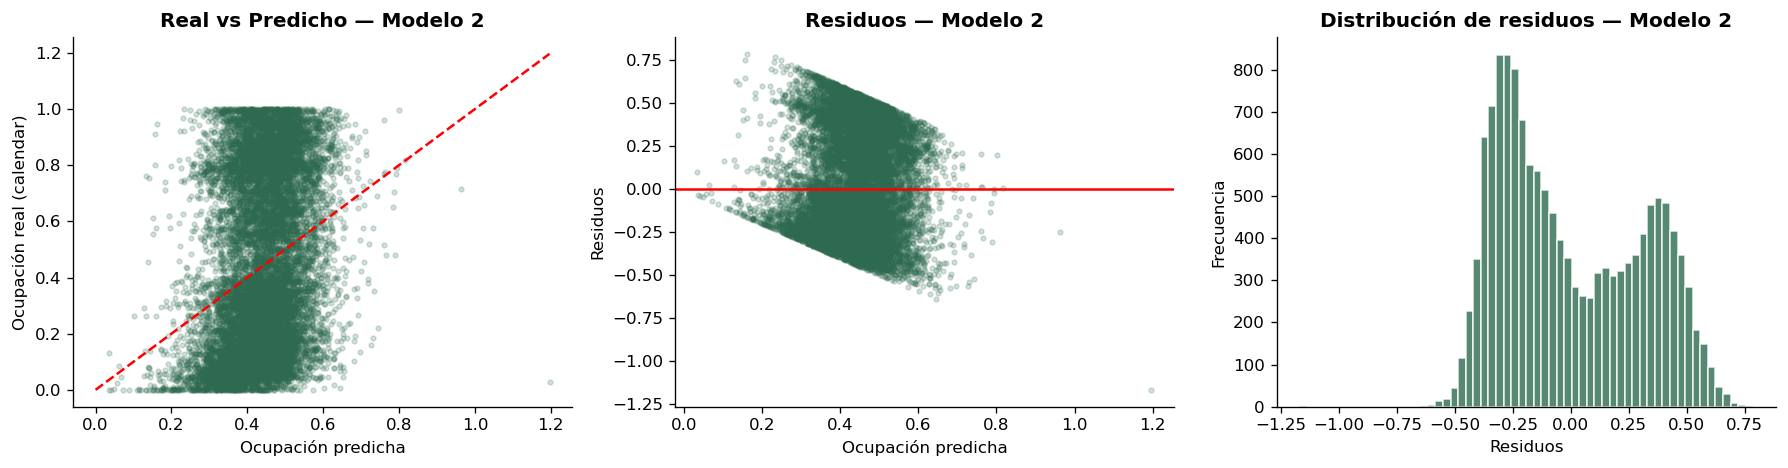

Fuente: elaboración propia


In [33]:
# 8.3 MODELO 2 — OCUPACIÓN REAL (LOG-PRECIO + ESTACIONALIDAD)
# Variable dependiente: occupancy_rate_cal (tasa de ocupación REAL
# obtenida de calendar.csv, más precisa que la estimación de listings).
# Novedad: se añade seasonality_index (ratio precio verano/invierno,
# fuente: calendar.csv) y reviews_last_12m como proxy de demanda reciente.

model_occ = smf.ols(
    formula="""
    occupancy_rate_cal ~ log_price + accommodates + bedrooms +
                         amenities_count + has_wifi + bathrooms_missing +
                         C(room_type) + C(neighbourhood_cleansed) +
                         review_scores_rating + host_is_superhost +
                         reviews_last_12m
    """,
    data=model_data_occ
).fit()

y_true_occ = model_data_occ['occupancy_rate_cal']
y_pred_occ = model_occ.fittedvalues

rmse_occ = np.sqrt(mean_squared_error(y_true_occ, y_pred_occ))
mae_occ  = mean_absolute_error(y_true_occ, y_pred_occ)

print('RMSE ocupación real:', round(rmse_occ, 4))
print('MAE  ocupación real:', round(mae_occ, 4))
print(model_occ.summary())

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_occ, y_true_occ, alpha=0.2, s=8, color=COLOR_TERC)
lim = max(float(y_true_occ.max()), float(y_pred_occ.max()))
axes[0].plot([0,lim],[0,lim],'r--', linewidth=1.5)
axes[0].set_xlabel('Ocupación predicha')
axes[0].set_ylabel('Ocupación real (calendar)')
axes[0].set_title('Real vs Predicho — Modelo 2')

residuals_occ = y_true_occ - y_pred_occ
axes[1].scatter(y_pred_occ, residuals_occ, alpha=0.2, s=8, color=COLOR_TERC)
axes[1].axhline(0, color='red', linewidth=1.5)
axes[1].set_xlabel('Ocupación predicha')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos — Modelo 2')

axes[2].hist(residuals_occ, bins=60, color=COLOR_TERC, alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Residuos')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de residuos — Modelo 2')

plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigM2_ocupacion_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente: elaboración propia')

### 8.3b Tests estadísticos de validación — Modelos OLS

In [34]:
# ─────────────────────────────────────────────────────────────
# TESTS ESTADÍSTICOS — Modelos OLS 1 y 2
# ─────────────────────────────────────────────────────────────

# Breusch-Pagan — Modelo precio
try:
    X_bp_enc = pd.get_dummies(
        model_data_price.drop(columns=['price']), drop_first=True).astype(float)
    X_bp_enc = sm.add_constant(X_bp_enc)
    bp_lm_p, bp_pval_p, _, _ = het_breuschpagan(model_price.resid, X_bp_enc)
except:
    bp_pval_p = float('nan')

# Breusch-Pagan — Modelo ocupación
try:
    X_bp_enc_occ = pd.get_dummies(
        model_data_occ.drop(columns=['occupancy_rate_cal']), drop_first=True).astype(float)
    X_bp_enc_occ = sm.add_constant(X_bp_enc_occ)
    bp_lm_o, bp_pval_o, _, _ = het_breuschpagan(model_occ.resid, X_bp_enc_occ)
except:
    bp_pval_o = float('nan')

# Jarque-Bera
jb_stat_p, jb_pval_p, jb_skew_p, jb_kurt_p = jarque_bera(model_price.resid)
jb_stat_o, jb_pval_o, jb_skew_o, jb_kurt_o = jarque_bera(model_occ.resid)

# AIC / BIC
aic_p, bic_p = model_price.aic, model_price.bic
aic_o, bic_o = model_occ.aic,   model_occ.bic

# VIF — variables numéricas Modelo 1
num_vars_p = ['accommodates','bedrooms','amenities_count','has_wifi',
              'review_scores_rating','host_is_superhost',
              'reviews_last_12m','listing_age_days']
num_vars_p = [v for v in num_vars_p if v in model_data_price.columns]
X_vif = model_data_price[num_vars_p].dropna().astype(float)
vif_df = pd.DataFrame({
    'Variable': num_vars_p,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(num_vars_p))]
}).round(2).sort_values('VIF', ascending=False)

# ── TABLA RESUMEN ─────────────────────────────────────────────
print('=' * 62)
print('TABLA. Métricas y tests estadísticos de los modelos OLS')
print('=' * 62)
print(f'{"Métrica":<35} {"M1 Precio":>12} {"M2 Ocupación":>12}')
print('-' * 62)
print(f'{"R²":<35} {model_price.rsquared:>12.3f} {model_occ.rsquared:>12.3f}')
print(f'{"R² ajustado":<35} {model_price.rsquared_adj:>12.3f} {model_occ.rsquared_adj:>12.3f}')
print(f'{"RMSE":<35} {np.sqrt(mean_squared_error(y_true_price,y_pred_price)):>12.3f} {np.sqrt(mean_squared_error(y_true_occ,y_pred_occ)):>12.4f}')
print(f'{"MAE":<35} {mean_absolute_error(y_true_price,y_pred_price):>12.3f} {mean_absolute_error(y_true_occ,y_pred_occ):>12.4f}')
print(f'{"F-statistic (p-valor)":<35} {"< 0.001":>12} {"< 0.001":>12}')
print(f'{"AIC":<35} {aic_p:>12.1f} {aic_o:>12.1f}')
print(f'{"BIC":<35} {bic_p:>12.1f} {bic_o:>12.1f}')
print(f'{"Breusch-Pagan p-valor":<35} {bp_pval_p:>12.4f} {bp_pval_o:>12.4f}')
print(f'{"Jarque-Bera p-valor":<35} {jb_pval_p:>12.4f} {jb_pval_o:>12.4f}')
print(f'{"Asimetría residuos":<35} {jb_skew_p:>12.3f} {jb_skew_o:>12.3f}')
print(f'{"Curtosis residuos":<35} {jb_kurt_p:>12.3f} {jb_kurt_o:>12.3f}')
print('=' * 62)
print()
print('VIF — variables numéricas Modelo 1:')
print(vif_df.to_string(index=False))
print()
print('Fuente: elaboración propia')

TABLA. Métricas y tests estadísticos de los modelos OLS
Métrica                                M1 Precio M2 Ocupación
--------------------------------------------------------------
R²                                         0.505        0.072
R² ajustado                                0.500        0.063
RMSE                                      69.257       0.3041
MAE                                       42.083       0.2682
F-statistic (p-valor)                    < 0.001      < 0.001
AIC                                     162905.7       6845.3
BIC                                     163943.3       7890.4
Breusch-Pagan p-valor                     0.0000       0.0000
Jarque-Bera p-valor                       0.0000       0.0000
Asimetría residuos                         3.417        0.351
Curtosis residuos                         29.618        1.835

VIF — variables numéricas Modelo 1:
            Variable   VIF
review_scores_rating 21.39
            has_wifi 11.91
     amenities_coun

SIMULACIÓN DEL PRECIO OPTIMO

Base modelo segmentado Entire home/apt: 10,802 obs.
occupancy_rate_cal        0
log_price                 0
price                     0
accommodates              0
bedrooms                  0
amenities_count           0
has_wifi                  0
bathrooms_missing         0
neighbourhood_cleansed    0
review_scores_rating      0
host_is_superhost         0
reviews_last_12m          0

RMSE ocupación entire home/apt: 0.2981
MAE  ocupación entire home/apt: 0.2615
                            OLS Regression Results                            
Dep. Variable:     occupancy_rate_cal   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     6.570
Date:                Sun, 24 May 2026   Prob (F-statistic):          2.96e-103
Time:                        00:48:31   Log-Likelihood:                -2253.5
No. Observations:               10802   AIC:               

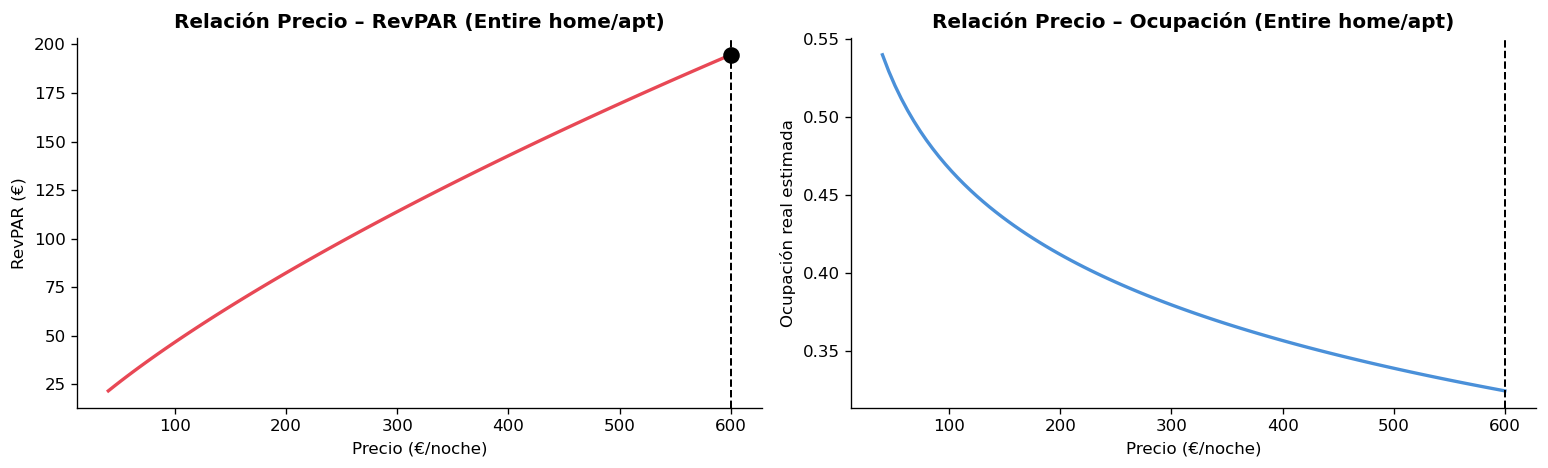

Fuente: elaboración propia


In [35]:
# 8.4 SIMULACIÓN DE PRECIO ÓPTIMO — Entire home/apt (con datos enriquecidos)
# Filtra el segmento Entire home/apt del dataset enriquecido
entire = enriched[enriched['room_type'] == 'Entire home/apt'].copy()
entire = entire[entire['price'] > 0].copy()
entire['log_price'] = np.log(entire['price'])

# Variable dependiente: occupancy_rate_cal (real, de calendar.csv)
entire_model_data = entire[[
    'occupancy_rate_cal', 'log_price', 'price', 'accommodates', 'bedrooms',
    'amenities_count', 'has_wifi', 'bathrooms_missing',
    'neighbourhood_cleansed', 'review_scores_rating', 'host_is_superhost',
    'reviews_last_12m'
]].dropna().copy()

print(f'Base modelo segmentado Entire home/apt: {entire_model_data.shape[0]:,} obs.')
print(entire_model_data.isna().sum().to_string())

# Modelo OLS segmentado
model_occ_entire_log = smf.ols(
    formula="""
    occupancy_rate_cal ~ log_price + accommodates + bedrooms +
                         amenities_count + has_wifi + bathrooms_missing +
                         C(neighbourhood_cleansed) +
                         review_scores_rating + host_is_superhost +
                         reviews_last_12m
    """,
    data=entire_model_data
).fit()

y_true_entire = entire_model_data['occupancy_rate_cal']
y_pred_entire = model_occ_entire_log.fittedvalues

rmse_entire = np.sqrt(mean_squared_error(y_true_entire, y_pred_entire))
mae_entire  = mean_absolute_error(y_true_entire, y_pred_entire)

print(f'\nRMSE ocupación entire home/apt: {rmse_entire:.4f}')
print(f'MAE  ocupación entire home/apt: {mae_entire:.4f}')
print(model_occ_entire_log.summary())

# Simulación RevPAR en rango de precios
price_range = np.linspace(40, 600, 100)
mean_values = entire_model_data.mean(numeric_only=True)
base = entire_model_data.iloc[0:1].copy()
for col in mean_values.index:
    if col in base.columns:
        base[col] = mean_values[col]
base['neighbourhood_cleansed'] = entire['neighbourhood_cleansed'].mode()[0]

results = []
for p in price_range:
    base['price']     = p
    base['log_price'] = np.log(p)
    pred_occ = model_occ_entire_log.predict(base).iloc[0]
    pred_occ = max(0, min(1, pred_occ))
    results.append((p, pred_occ, p * pred_occ))

results_df = pd.DataFrame(results, columns=['price','occupancy','revpar'])
optimal    = results_df.loc[results_df['revpar'].idxmax()]

print(f'\n=== PRECIO ÓPTIMO (perfil representativo Entire home/apt) ===')
print(f'Precio óptimo : {optimal["price"]:.2f} €')
print(f'Ocupación est.: {optimal["occupancy"]:.3f}')
print(f'RevPAR máximo : {optimal["revpar"]:.2f} €')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(results_df['price'], results_df['revpar'], color=COLOR_MAIN, linewidth=2)
axes[0].axvline(optimal['price'], linestyle='--', color='black', linewidth=1.2)
axes[0].scatter(optimal['price'], optimal['revpar'], s=80, color='black', zorder=5)
axes[0].set_xlabel('Precio (€/noche)')
axes[0].set_ylabel('RevPAR (€)')
axes[0].set_title('Relación Precio – RevPAR (Entire home/apt)')

axes[1].plot(results_df['price'], results_df['occupancy'], color=COLOR_SEC, linewidth=2)
axes[1].axvline(optimal['price'], linestyle='--', color='black', linewidth=1.2)
axes[1].set_xlabel('Precio (€/noche)')
axes[1].set_ylabel('Ocupación real estimada')
axes[1].set_title('Relación Precio – Ocupación (Entire home/apt)')

plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'FigM3_simulacion_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente: elaboración propia')

### 8.5 Modelo 3 — Random Forest (predicción de precio)

In [36]:
# 8.5 RANDOM FOREST — PREDICCIÓN DE PRECIO (con variables enriquecidas)
# Se añaden las variables de calendar y reviews al conjunto de regresores.
# Justificación: el RF captura no linealidades e interacciones que el OLS
# no puede modelar, y permite cuantificar la importancia de las nuevas
# variables procedentes de calendar.csv y reviews.csv.

RF_VARS = [
    # Variables de listings (base)
    'accommodates', 'bedrooms', 'bathrooms', 'amenities_count',
    'has_wifi', 'review_scores_rating', 'host_is_superhost',
    'host_tenure_days', 'room_type', 'neighbourhood_cleansed', 'instant_bookable',
    # Variables nuevas de reviews.csv (cobertura 100%)
    'reviews_last_12m', 'listing_age_days'
    # seasonality_index y price_std_cal excluidas (cobertura 0%)
]

rf_vars_ok = [v for v in RF_VARS if v in enriched.columns]
print(f'Variables usadas en RF: {rf_vars_ok}')

rf_data = enriched[rf_vars_ok + ['price']].dropna()
print(f'Muestra RF: {rf_data.shape[0]:,} observaciones')

rf_enc = pd.get_dummies(rf_data,
                         columns=['room_type','neighbourhood_cleansed'],
                         drop_first=True)
X_rf = rf_enc.drop(columns=['price'])
y_rf = rf_enc['price']

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print('Entrenando Random Forest...')

rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                            min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print()
print('Tabla. Comparativa OLS (M1) vs Random Forest — predicción de precio')
print(f'{"":30} {"OLS (M1)":>12} {"RF":>12}')
print('-'*56)
print(f'{"RMSE (€)":<30} {np.sqrt(mean_squared_error(y_true_price,y_pred_price)):>12.3f} {rmse_rf:>12.3f}')
print(f'{"MAE (€)":<30} {mean_absolute_error(y_true_price,y_pred_price):>12.3f} {mae_rf:>12.3f}')
print(f'{"R²":<30} {model_price.rsquared:>12.3f} {r2_rf:>12.3f}')
print('-'*56)
print('Fuente: elaboración propia')

Variables usadas en RF: ['accommodates', 'bedrooms', 'bathrooms', 'amenities_count', 'has_wifi', 'review_scores_rating', 'host_is_superhost', 'host_tenure_days', 'room_type', 'neighbourhood_cleansed', 'instant_bookable', 'reviews_last_12m', 'listing_age_days']
Muestra RF: 14,287 observaciones
Train: 11,429 | Test: 2,858
Entrenando Random Forest...

Tabla. Comparativa OLS (M1) vs Random Forest — predicción de precio
                                   OLS (M1)           RF
--------------------------------------------------------
RMSE (€)                             69.257       65.429
MAE (€)                              42.083       38.112
R²                                    0.505        0.581
--------------------------------------------------------
Fuente: elaboración propia


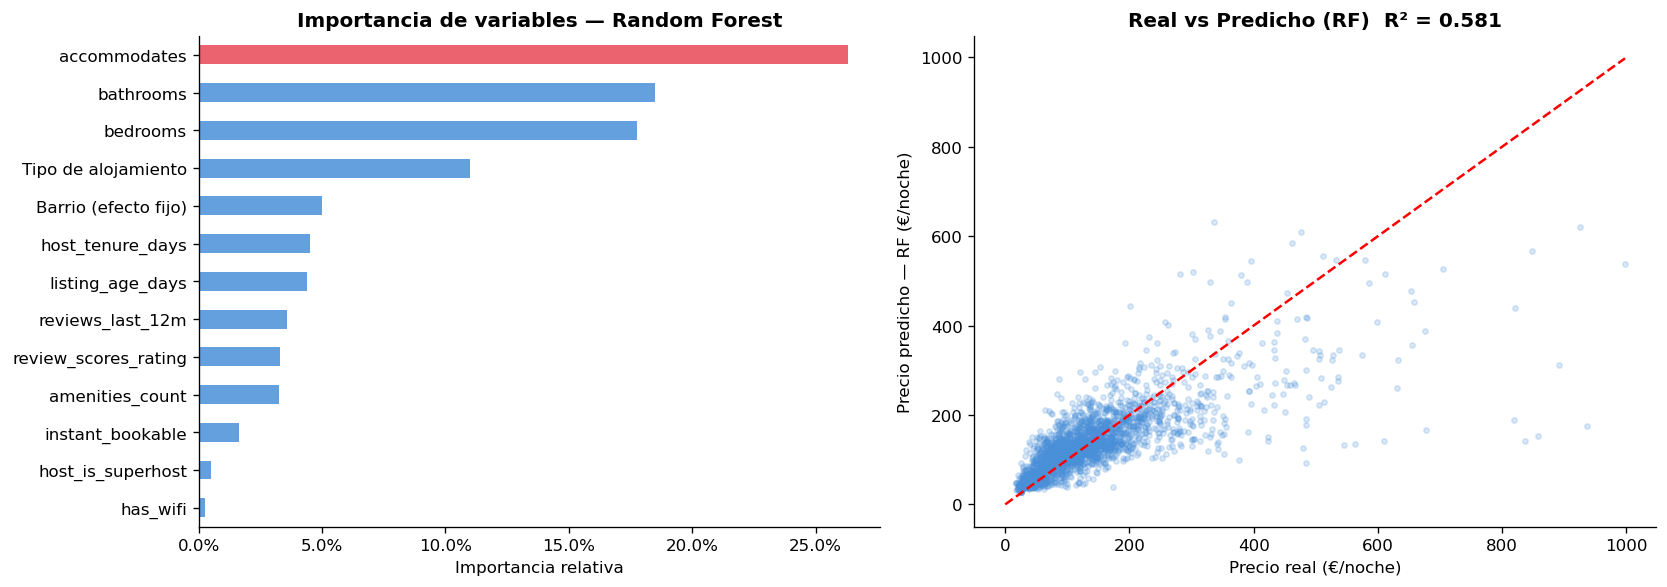

Fuente: elaboración propia


In [37]:
# ─────────────────────────────────────────────────────────────
# RF: IMPORTANCIA DE VARIABLES + REAL VS PREDICHO
# ─────────────────────────────────────────────────────────────
# Agrupar dummies para legibilidad
def group_feat(name):
    if 'neighbourhood_cleansed' in name: return 'Barrio (efecto fijo)'
    if 'room_type' in name:              return 'Tipo de alojamiento'
    return name

feat_imp = pd.Series(rf.feature_importances_, index=X_rf.columns)
feat_grouped = feat_imp.groupby(feat_imp.index.map(group_feat)).sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Importancia de variables
colors_bar = [COLOR_MAIN if v == feat_grouped.max() else COLOR_SEC
              for v in feat_grouped.values]
feat_grouped.plot(kind='barh', ax=axes[0], color=colors_bar, alpha=0.85)
axes[0].set_xlabel('Importancia relativa')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_title('Importancia de variables — Random Forest')

# Real vs predicho
axes[1].scatter(y_test, y_pred_rf, alpha=0.2, s=10, color=COLOR_SEC)
lim = max(float(y_test.max()), float(y_pred_rf.max()))
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[1].set_xlabel('Precio real (€/noche)')
axes[1].set_ylabel('Precio predicho — RF (€/noche)')
axes[1].set_title(f'Real vs Predicho (RF)  R² = {r2_rf:.3f}')

plt.tight_layout()
plt.savefig('Fig10_11_RF.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fuente: elaboración propia")

9. Simulador 

In [38]:
def simulador_precio_optimo_entire(
    accommodates,
    bedrooms,
    amenities_count,
    has_wifi,
    bathrooms_missing,
    review_scores_rating,
    host_is_superhost,
    neighbourhood,
    reviews_last_12m=10,       # valor por defecto: actividad media
    price_min=40,
    price_max=600,
    n_prices=100
):
    price_range = np.linspace(price_min, price_max, n_prices)
    resultados = []

    for p in price_range:
        fila = pd.DataFrame({
            'price':                [p],
            'log_price':            [np.log(p)],
            'accommodates':         [accommodates],
            'bedrooms':             [bedrooms],
            'amenities_count':      [amenities_count],
            'has_wifi':             [has_wifi],
            'bathrooms_missing':    [bathrooms_missing],
            'review_scores_rating': [review_scores_rating],
            'host_is_superhost':    [host_is_superhost],
            'neighbourhood_cleansed': [neighbourhood],
            'reviews_last_12m':     [reviews_last_12m],
        })

        pred_occ = model_occ_entire_log.predict(fila).iloc[0]
        pred_occ = max(0, min(1, pred_occ))
        revpar = p * pred_occ

        resultados.append({'price': p, 'occupancy': pred_occ, 'revpar': revpar})

    resultados = pd.DataFrame(resultados)
    optimo = resultados.loc[resultados['revpar'].idxmax()]

    print('=== RESULTADO DEL SIMULADOR ===')
    print(f'Barrio: {neighbourhood}')
    print(f'Precio óptimo estimado: {optimo["price"]:.2f} €')
    print(f'Ocupación estimada:     {optimo["occupancy"]:.3f}')
    print(f'RevPAR máximo:          {optimo["revpar"]:.2f} €')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(resultados['price'], resultados['revpar'], color='#E84855', linewidth=2)
    axes[0].axvline(optimo['price'], linestyle='--', color='black')
    axes[0].scatter(optimo['price'], optimo['revpar'], s=80, color='black', zorder=5)
    axes[0].set_xlabel('Precio (€/noche)')
    axes[0].set_ylabel('RevPAR estimado (€)')
    axes[0].set_title('Simulación precio óptimo | Entire home/apt')

    axes[1].plot(resultados['price'], resultados['occupancy'], color='#4A90D9', linewidth=2)
    axes[1].axvline(optimo['price'], linestyle='--', color='black')
    axes[1].set_xlabel('Precio (€/noche)')
    axes[1].set_ylabel('Ocupación estimada')
    axes[1].set_title('Relación precio – ocupación | Entire home/apt')

    plt.tight_layout()
    plt.show()
    return resultados, optimo

=== RESULTADO DEL SIMULADOR ===
Barrio: Sol
Precio óptimo estimado: 600.00 €
Ocupación estimada:     0.354
RevPAR máximo:          212.23 €


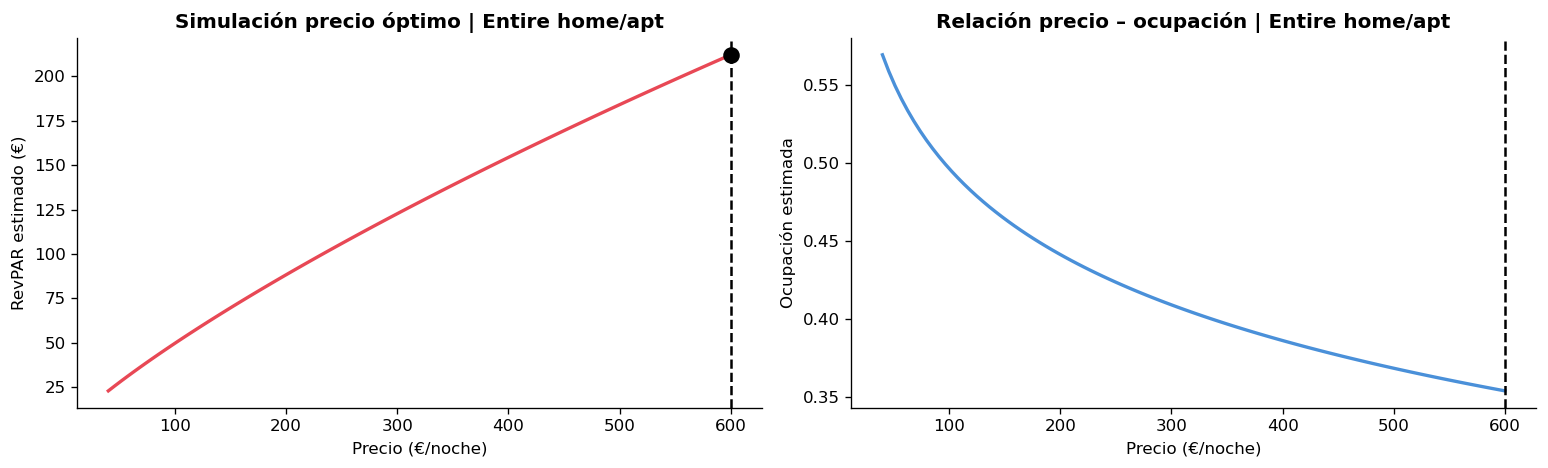


=== INTERPRETACIÓN DE NEGOCIO ===
→ Estrategia premium: conviene priorizar precio sobre ocupación


In [39]:
#9.3 Ejemplo del simualdor sin interfaz:
resultados_sim, optimo_sim = simulador_precio_optimo_entire(
    accommodates=4,
    bedrooms=2,
    amenities_count=25,
    has_wifi=1,
    bathrooms_missing=0,
    review_scores_rating=4.7,
    host_is_superhost=1,
    neighbourhood='Sol',
    reviews_last_12m=10,    # ← añadir esta línea
    price_min=40,
    price_max=600,
    n_prices=100
)
print("\n=== INTERPRETACIÓN DE NEGOCIO ===")

if optimo_sim ["price"] > 300:
    print("→ Estrategia premium: conviene priorizar precio sobre ocupación")
elif optimo_sim["price"] > 150:
    print("→ Estrategia equilibrada: balance entre ocupación y precio")
else:
    print("→ Estrategia volumen: maximizar ocupación con precios competitivos")

In [40]:
import pickle

with open("model_occ_entire_log.pkl", "wb") as f:
    pickle.dump(model_occ_entire_log, f)

In [41]:
#Todos los barrios disponbles para el desplegable de la interfaz:
print(entire_model_data["neighbourhood_cleansed"].unique())

['Sol' 'Universidad' 'Embajadores' 'Cortes' 'Chopera' 'Valdefuentes'
 'Palacio' 'Justicia' 'Niño Jesús' 'Concepción' 'Recoletos'
 'Palos de Moguer' 'San Diego' 'Simancas' 'Timón' 'Marroquina' 'Goya'
 'Almenara' 'San Andrés' 'Almagro' 'Nueva España' 'Rios Rosas' 'Valverde'
 'Lista' 'Fontarrón' 'Berruguete' 'Trafalgar' 'Canillas' 'Argüelles'
 'Ibiza' 'Guindalera' 'Castilla' 'Castellana' 'Jerónimos'
 'San Juan Bautista' 'Aravaca' 'Ciudad Jardín' 'Cármenes' 'Arapiles'
 'Hispanoamérica' 'Imperial' 'Casa de Campo' 'Quintana' 'Lucero'
 'Castillejos' 'Puerta del Angel' 'Acacias' 'Delicias' 'El Viso'
 'Campamento' 'Piovera' 'Costillares' 'Ventas' 'Pueblo Nuevo'
 'Fuente del Berro' 'Adelfas' 'Los Angeles' 'Almendrales' 'Pacífico'
 'Gaztambide' 'Prosperidad' 'Valdeacederas' 'Rejas' 'San Isidro'
 'Cuatro Caminos' 'San Cristobal' 'Moscardó' 'Santa Eugenia' 'Comillas'
 'Hellín' 'Pilar' 'Bellas Vistas' 'Atocha' 'Casco Histórico de Vallecas'
 'Numancia' 'Peñagrande' 'Cuatro Vientos' 'Legazpi' 'Vallehe

### 10. Clustering K-means — Segmentación del mercado

Variables de clustering: ['price', 'occupancy_rate_cal', 'revpar', 'accommodates', 'review_scores_rating', 'amenities_count', 'reviews_last_12m']
Muestra para clustering: 14,398 observaciones


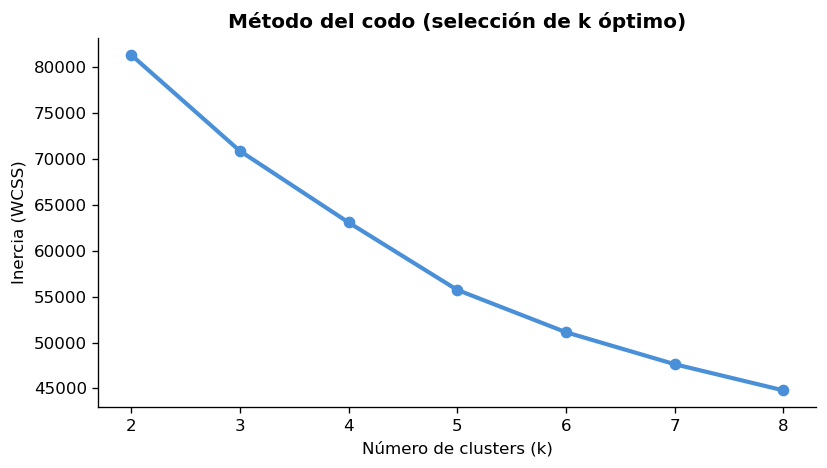

In [42]:
# 10. K-MEANS — SEGMENTACIÓN DE ALOJAMIENTOS (con variables enriquecidas)
# Variable clave añadida: occupancy_rate_cal (ocupación real de calendar.csv)
# en lugar de la ocupación estimada, que es más precisa para segmentar.

CLUSTER_VARS = [
    'price', 'occupancy_rate_cal', 'revpar',
    'accommodates', 'review_scores_rating', 'amenities_count',
    'reviews_last_12m'
    # seasonality_index excluida (cobertura 0%)
]
clust_vars_ok = [v for v in CLUSTER_VARS if v in enriched.columns]
print(f'Variables de clustering: {clust_vars_ok}')

clust_data = enriched[clust_vars_ok].dropna().copy()
print(f'Muestra para clustering: {clust_data.shape[0]:,} observaciones')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(clust_data)

# Método del codo
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, 'o-', color=COLOR_SEC, linewidth=2.5)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia (WCSS)')
ax.set_title('Método del codo (selección de k óptimo)')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.savefig(RUTA_OUTPUT + 'Fig12_codo_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
K_OPTIMO = 4

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=20)
clust_data['cluster'] = km_final.fit_predict(X_scaled)

# Perfil de cada cluster
agg_dict = {
    'N':               ('price',              'count'),
    'precio_mediano':  ('price',              'median'),
    'revpar_mediano':  ('revpar',             'median'),
    'capacidad_media': ('accommodates',       'mean'),
    'rating_medio':    ('review_scores_rating','mean'),
    'amenities_medio': ('amenities_count',    'mean'),
}
if 'occupancy_rate_cal' in clust_data.columns:
    agg_dict['ocupacion_real_media'] = ('occupancy_rate_cal', 'mean')
if 'seasonality_index' in clust_data.columns:
    agg_dict['estacionalidad_media'] = ('seasonality_index', 'mean')

perfil = clust_data.groupby('cluster').agg(**agg_dict).round(3)

print('Tabla. Perfil de los clusters identificados (con variables enriquecidas)')
print(perfil.to_string())

# Nombrar por RevPAR
nombres_cluster = {}
orden = perfil['revpar_mediano'].sort_values(ascending=False)
etiquetas = ['C1 — Premium', 'C2 — Calidad media-alta',
             'C3 — Económico / alta ocupación', 'C4 — Bajo rendimiento']
for idx, (k, _) in enumerate(orden.items()):
    nombres_cluster[k] = etiquetas[idx]

clust_data['segmento'] = clust_data['cluster'].map(nombres_cluster)
print()
for k, nombre in nombres_cluster.items():
    n = (clust_data['cluster'] == k).sum()
    print(f'  {nombre}: {n:,} alojamientos ({n/len(clust_data)*100:.1f}%)')

Tabla. Perfil de los clusters identificados (con variables enriquecidas)
            N  precio_mediano  revpar_mediano  capacidad_media  rating_medio  amenities_medio  ocupacion_real_media
cluster                                                                                                            
0        3116           115.0          76.151            3.388         4.769           36.007                 0.507
1        1342           294.0         127.192            6.937         4.723           36.437                 0.417
2        3946            95.0          20.844            2.850         4.675           27.283                 0.783
3        5994           103.0          16.570            3.014         4.541           26.389                 0.177

  C1 — Premium: 1,342 alojamientos (9.3%)
  C2 — Calidad media-alta: 3,116 alojamientos (21.6%)
  C3 — Económico / alta ocupación: 3,946 alojamientos (27.4%)
  C4 — Bajo rendimiento: 5,994 alojamientos (41.6%)


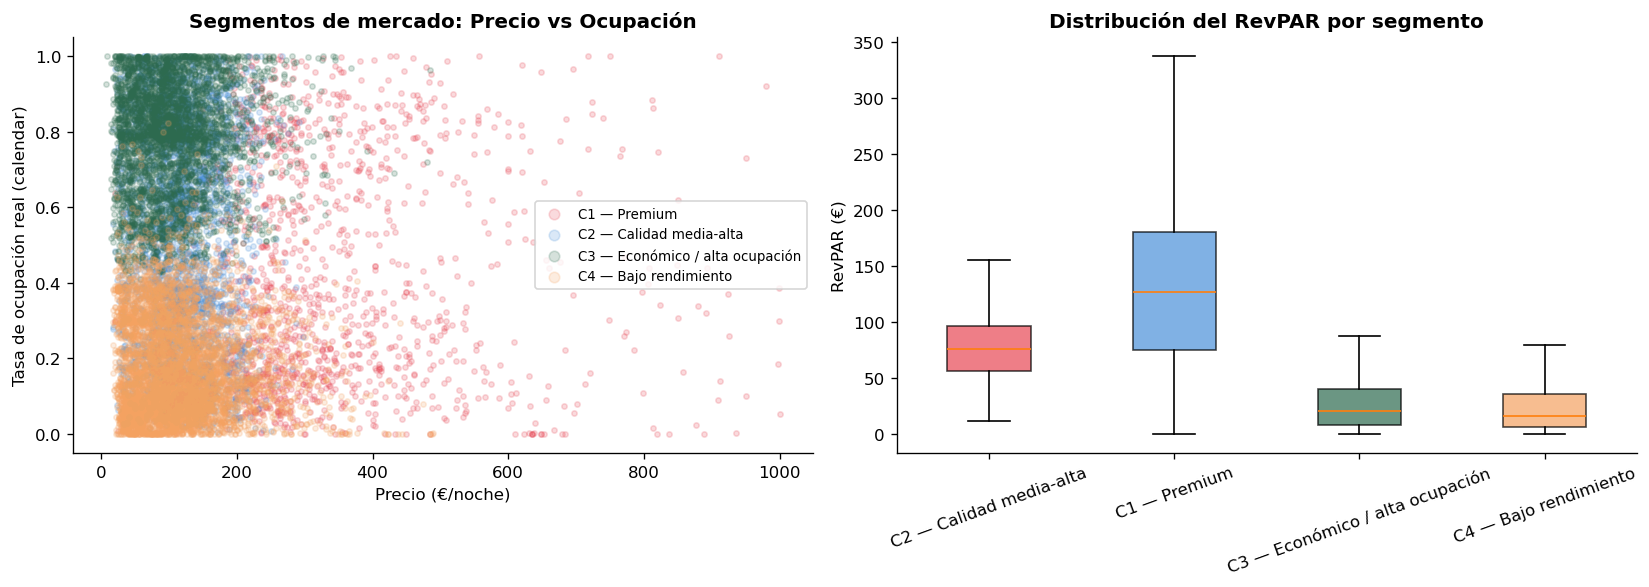

Fuente: elaboración propia


In [ ]:
# VISUALIZACIÓN CLUSTERING 
colores_seg = [COLOR_MAIN, COLOR_SEC, COLOR_TERC, '#F4A261']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter precio vs ocupación coloreado por segmento
for i, (k, nombre) in enumerate(nombres_cluster.items()):
    mask = clust_data['cluster'] == k
    axes[0].scatter(clust_data.loc[mask, 'price'],
                    clust_data.loc[mask, 'occupancy_rate_cal'],
                    alpha=0.2, s=10, color=colores_seg[i], label=nombre)
axes[0].set_xlabel('Precio (€/noche)')
axes[0].set_ylabel('Tasa de ocupación real (calendar)')
axes[0].set_title('Segmentos de mercado: Precio vs Ocupación')
axes[0].legend(fontsize=8, markerscale=2)

# Boxplot RevPAR por segmento
seg_names  = [nombres_cluster[k] for k in sorted(nombres_cluster)]
data_bplot = [clust_data.loc[clust_data['cluster']==k, 'revpar'].values
              for k in sorted(nombres_cluster)]
bp = axes[1].boxplot(data_bplot, labels=seg_names, patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], colores_seg):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_ylabel('RevPAR (€)')
axes[1].set_title('Distribución del RevPAR por segmento')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('Fig13_14_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fuente: elaboración propia")